In [34]:
import numpy as np
import matplotlib.pyplot as plt

from CBSetup import *
from myutils import *
from simulator import *
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import tqdm as tqdm

We can now build the setup for task 9 according to the CB.setup.pdf file. We set the parameters to a default value of:
- Gb = 50
- Gs = 1
- C = 1
- Cg = 0.01

In [16]:
def setuptask9(Gb=50, Gs=1, C=1, Cg=0.01):
    #First we create the setup
    #two leads
    Setup=CBSetup()
    Setup.add_lead('LeadLeft')
    Setup.add_lead('LeadRight')

    #two islands
    Setup.add_island('Island1')
    Setup.add_island('Island2')

    #We connect the leads to the islands with 3 tunnel junctions
    Setup.add_junctionBIL('Junction1','Island1','LeadLeft',Gb,C)
    Setup.add_junctionBTI('Junction2','Island1','Island2',Gb,C)
    Setup.add_junctionBIL('Junction3','Island2','LeadRight',Gs,C)

    #We add gates to the islands
    Setup.add_gate('Gate_1', 'Island1', Cg)
    Setup.add_gate('Gate_2', 'Island2', Cg)

    Setup.finish()

    return Setup

In [17]:
def run_iv_curve(Gb=100, Gs=1, C=1, Cg=0.01,
                 q1=0.0, q2=0.0, T=1e-3,
                 Vmax=5.0, Numsteps=100, timeinterval=1000):
    """Run a full I-V sweep and return (voltages, currents)."""
    zeros = np.zeros(2)
    # Convert induced charge -> gate voltage: V_g = q / Cg
    Vg1 = q1 / Cg
    Vg2 = q2 / Cg
    gate_voltages = np.array([Vg1, Vg2])
    Setup = setuptask9(Gb=Gb, Gs=Gs, C=C, Cg=Cg)
    Setup.temperature = T

    runcurrents = Setup.runit(
        Numsteps, zeros, gate_voltages,
        np.array([Vmax/2, -Vmax/2]), gate_voltages,
        timeinterval=timeinterval, debug=False,
    )
    I = np.array(runcurrents)[:, 0]
    V = np.linspace(0, Vmax, Numsteps + 1)
    return V, I


def extract_step_properties(V, I, n_steps=3, prominence = 0.6, distance=10, averaging = 5, plotting = False):
    """
    Return lists of (V_step, G_high, G_low) for up to n_steps steps.
    G_high = local peak of dI/dV just at the step start.
    G_low  = dI/dV in the plateau just before the next step.
    """
    dV   = V[1] - V[0]
    dIdV = np.diff(I,n=1) / dV
    averaged_dIdV = np.convolve(dIdV, np.ones(averaging)/averaging, mode='valid')  # Simple moving average to smooth noise
    
    V_m  = 0.5 * (V[:-1] + V[1:])
    
    peaks, _ = find_peaks(averaged_dIdV, prominence=prominence * averaged_dIdV.max(), distance=distance)

    if plotting:
        plt.figure(figsize=(8,4))
        plt.plot(np.linspace(V[0], V[-1], len(averaged_dIdV)), averaged_dIdV, label='dI/dV')
        plt.scatter(np.linspace(V[0], V[-1], len(averaged_dIdV))[peaks], averaged_dIdV[peaks], color='red', label='Peaks')
        plt.xlabel('Voltage (V)')
        plt.ylabel('dI/dV (S)')
        plt.title('Differential Conductance with Detected Peaks')
        plt.legend()
        plt.show()

    results = []
    for k, p in enumerate(peaks[:n_steps]):
        V_step = V_m[p]
        G_high = averaged_dIdV[p]

        # Low conductance = minimum of dI/dV in [V_step, next_V_step)
        if k + 1 < len(peaks):
            next_p = peaks[k + 1]
        else:
            next_p = len(averaged_dIdV)
        plateau = averaged_dIdV[p:next_p]
        G_low = plateau.min() if len(plateau) > 0 else np.nan

        results.append((V_step, G_high, G_low))

    # Pad with NaN if fewer steps found
    while len(results) < n_steps:
        results.append((np.nan, np.nan, np.nan))

    return results

## a)
We can now do exercise a). We set the temperature T = 10e-3 and the gate voltages Volt_Gate_1 = 0 and Volt_Gate_2 = 0. 
We run the voltage difference between the leads from 0 to Vmax in Numsteps steps during the simulation. We can then plot the I-V curve for this setup, varying Gb = 50,100,200 en 400.

In [13]:
Numsteps = 500
Vmax = 5
timeinterval = 10000
Gb_values = [50, 100, 200, 400]
V_list = []
I_list = []
for idx, Gb in enumerate(Gb_values):
    V, I = run_iv_curve(Gb = Gb, Numsteps=Numsteps, timeinterval=timeinterval, Vmax = Vmax)  
    V_list.append(V)
    I_list.append(I)

In [169]:
np.savez('DataexerciseA', V_list = V_list, I_list = I_list)

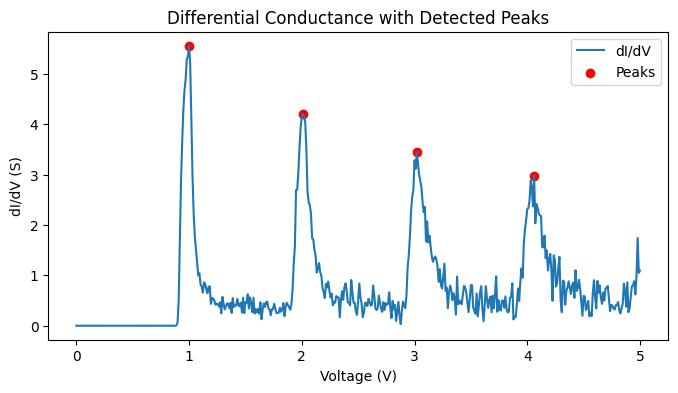

  Step 1: V_step=0.9850 V, G_high=5.560439 S, G_low=0.130071 S
  V_step = 0.9850 V
  stepsizeV = 0.0100 V
  Step 2: V_step=1.9750 V, G_high=4.206151 S, G_low=0.031662 S
  V_step = 1.9750 V
  stepsizeV = 0.0100 V
  Step 3: V_step=2.9650 V, G_high=3.450533 S, G_low=0.088372 S
  V_step = 2.9650 V
  stepsizeV = 0.0100 V
  Step 4: V_step=3.9850 V, G_high=2.983069 S, G_low=0.188326 S
  V_step = 3.9850 V
  stepsizeV = 0.0100 V


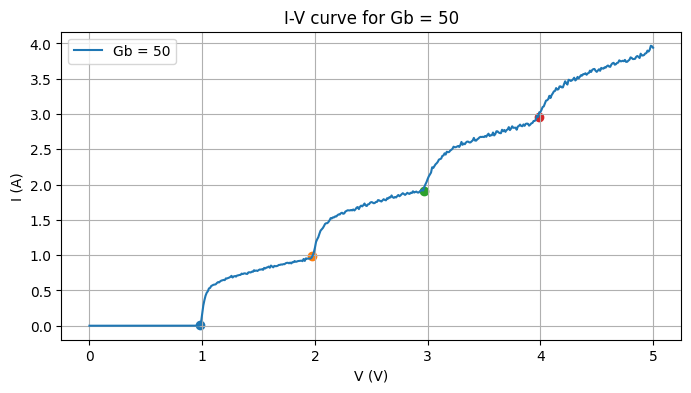

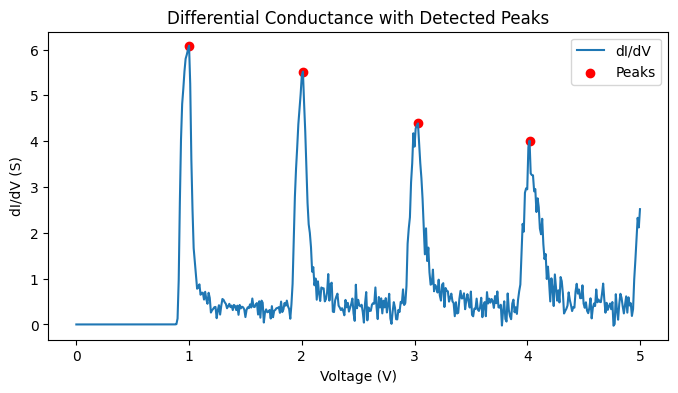

  Step 1: V_step=0.9850 V, G_high=6.083464 S, G_low=0.041888 S
  V_step = 0.9850 V
  stepsizeV = 0.0100 V
  Step 2: V_step=1.9750 V, G_high=5.517998 S, G_low=0.013489 S
  V_step = 1.9750 V
  stepsizeV = 0.0100 V
  Step 3: V_step=2.9750 V, G_high=4.387878 S, G_low=-0.023681 S
  V_step = 2.9750 V
  stepsizeV = 0.0100 V
  Step 4: V_step=3.9450 V, G_high=4.012130 S, G_low=-0.027874 S
  V_step = 3.9450 V
  stepsizeV = 0.0100 V


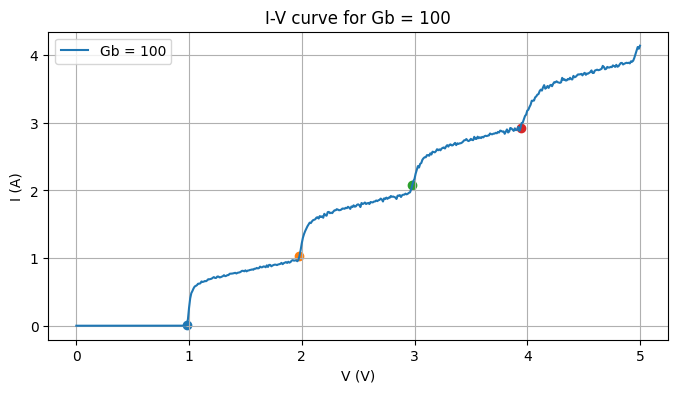

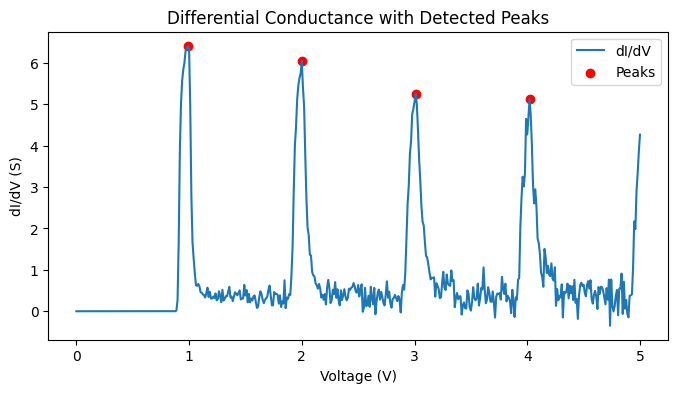

  Step 1: V_step=0.9750 V, G_high=6.417172 S, G_low=0.075503 S
  V_step = 0.9750 V
  stepsizeV = 0.0100 V
  Step 2: V_step=1.9650 V, G_high=6.046149 S, G_low=-0.073378 S
  V_step = 1.9650 V
  stepsizeV = 0.0100 V
  Step 3: V_step=2.9550 V, G_high=5.258277 S, G_low=-0.152388 S
  V_step = 2.9550 V
  stepsizeV = 0.0100 V
  Step 4: V_step=3.9450 V, G_high=5.129039 S, G_low=-0.349996 S
  V_step = 3.9450 V
  stepsizeV = 0.0100 V


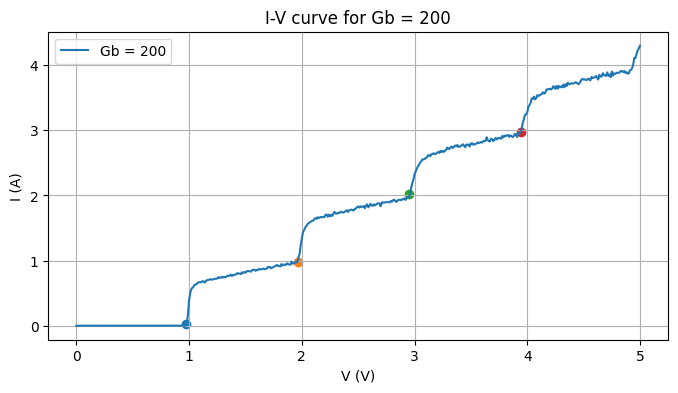

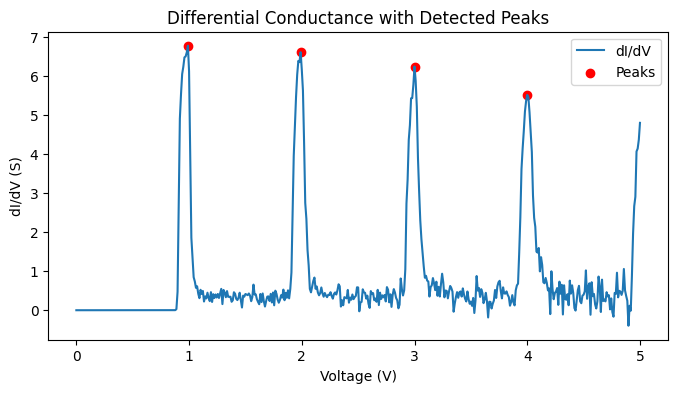

  Step 1: V_step=0.9750 V, G_high=6.782172 S, G_low=0.069823 S
  V_step = 0.9750 V
  stepsizeV = 0.0100 V
  Step 2: V_step=1.9550 V, G_high=6.615640 S, G_low=-0.027493 S
  V_step = 1.9550 V
  stepsizeV = 0.0100 V
  Step 3: V_step=2.9450 V, G_high=6.248796 S, G_low=-0.185715 S
  V_step = 2.9450 V
  stepsizeV = 0.0100 V
  Step 4: V_step=3.9250 V, G_high=5.522422 S, G_low=-0.397308 S
  V_step = 3.9250 V
  stepsizeV = 0.0100 V


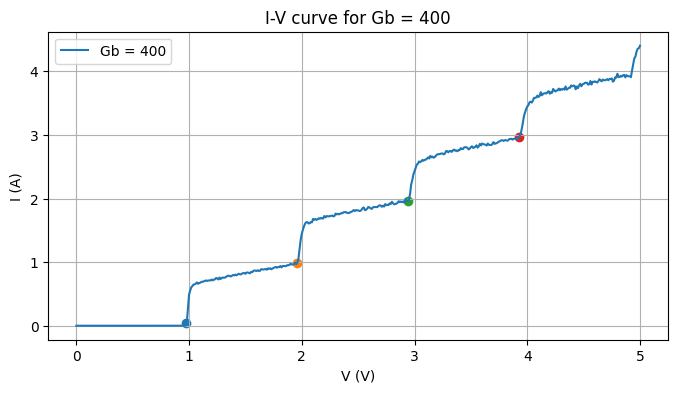

In [170]:
#plot to verify if the simulation is working correctly
Numsteps = 500
Vmax = 5
timeinterval = 10000
Gb_values = [50, 100, 200, 400]
DataexerciseA = np.load('DataexerciseA.npz')
V_list = DataexerciseA['V_list']
I_list = DataexerciseA['I_list']

stepsizeV = Vmax/Numsteps

for idx, (Gb,V,I) in enumerate(zip(Gb_values,V_list,I_list)):
    data = np.full((4,4),np.nan)
    steps = extract_step_properties(V, I, n_steps=4,prominence=0.5, distance = 5,averaging = 10, plotting = True)

    plt.figure(figsize=(8,4))
    for s, (Vstep, Ghigh, Glow) in enumerate(steps):
        print(f'  Step {s+1}: V_step={Vstep:.4f} V, G_high={Ghigh:.6f} S, G_low={Glow:.6f} S')
        print(f'  V_step = {Vstep:.4f} V')
        print(f'  stepsizeV = {stepsizeV:.4f} V')
        index =int(np.round(Vstep/stepsizeV))
        plt.scatter(Vstep, I[index])

    plt.plot(V, I, label=f'Gb = {Gb}')
    plt.xlabel('V (V)')
    plt.ylabel('I (A)')
    plt.title(f'I-V curve for Gb = {Gb}')
    plt.grid(True)
    plt.legend()
    plt.show()

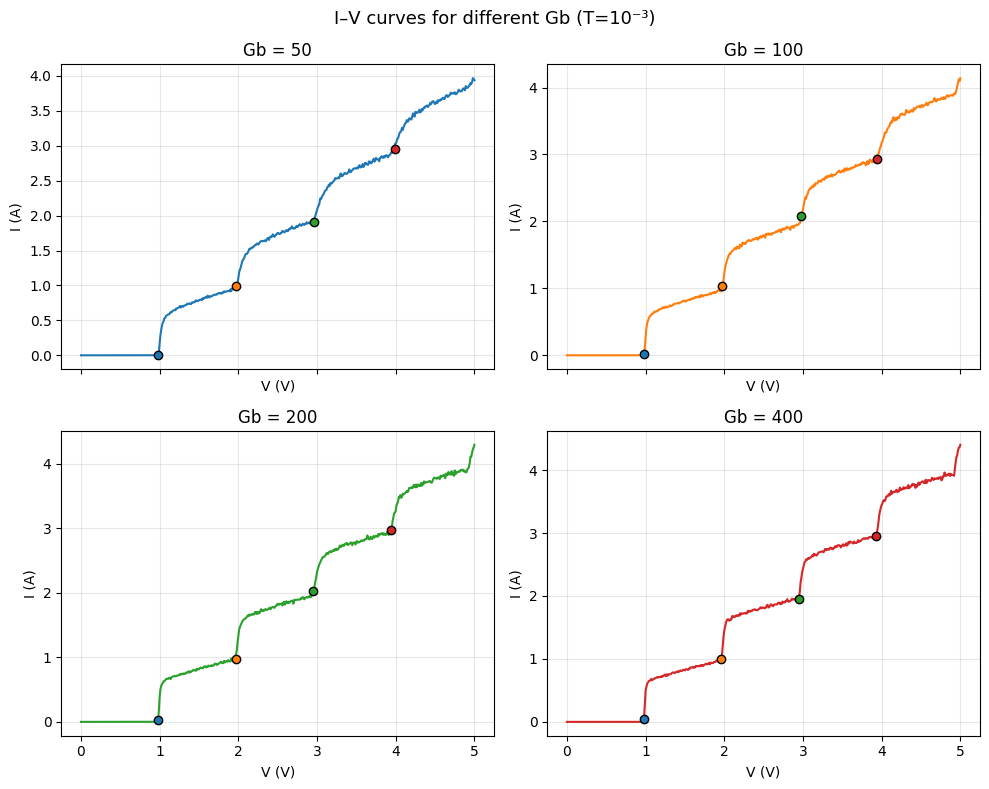

In [171]:
#plot for report
# --- Plot all four I–V curves together ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
axes = axes.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for idx, (Gb,V,I) in enumerate(zip(Gb_values,V_list,I_list)):
    ax = axes[idx]
    ax.plot(V, I, color=colors[idx], lw=1.5)
    ax.set_title(f'Gb = {Gb}')
    ax.set_xlabel('V (V)')
    ax.set_ylabel('I (A)')
    ax.grid(True, alpha=0.3)

    steps = extract_step_properties(V, I, n_steps=4,prominence=0.5, distance = 5,averaging = 10)
    for s, (Vstep, Ghigh, Glow) in enumerate(steps):
        index =int(np.round(Vstep/stepsizeV))
        ax.scatter(Vstep, I[index], label=f'Step {s+1}', edgecolor='black', zorder=5)

fig.suptitle('I–V curves for different Gb (T=10⁻³)', fontsize=13)
plt.tight_layout()
plt.show()

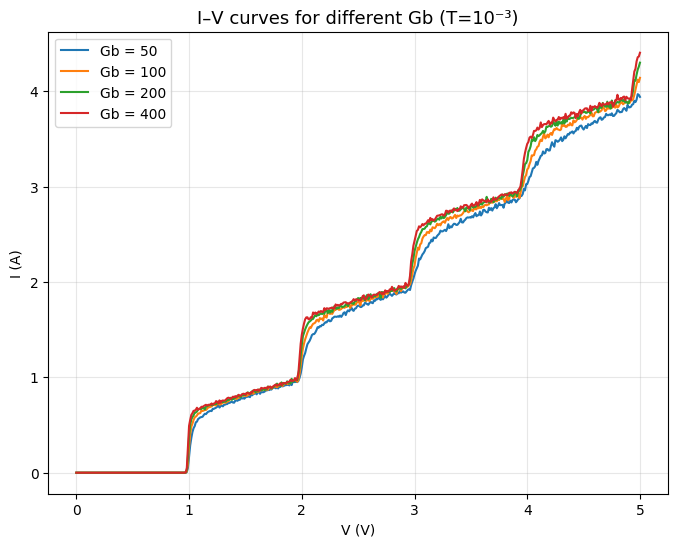

In [172]:
# plotting the I-V curve on to of each other to see the differences more clearly
plt.figure(figsize=(8,6))
for idx, (Gb,V,I) in enumerate(zip(Gb_values,V_list,I_list)):
    plt.plot(V, I, color=colors[idx], lw=1.5, label =f'Gb = {Gb}')

plt.grid(True, alpha=0.3)
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.legend()
plt.title('I–V curves for different Gb (T=10⁻³)', fontsize=13)

plt.show()

    Gb   Step    V_step    G_high (dI/dV)


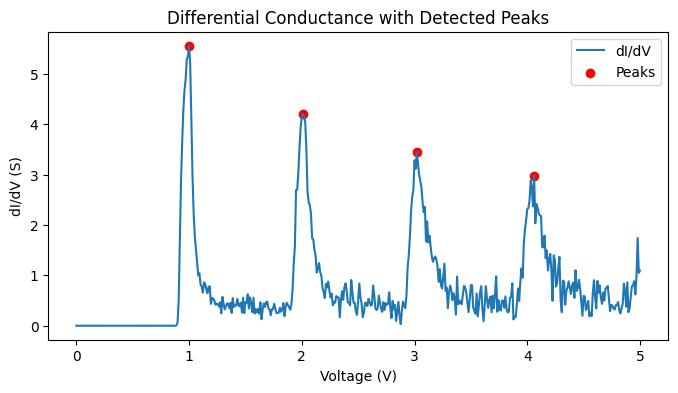

50  1  0.9850 V, G_high=5.560439 S
50  2  1.9750 V, G_high=4.206151 S
50  3  2.9650 V, G_high=3.450533 S
50  4  3.9850 V, G_high=2.983069 S


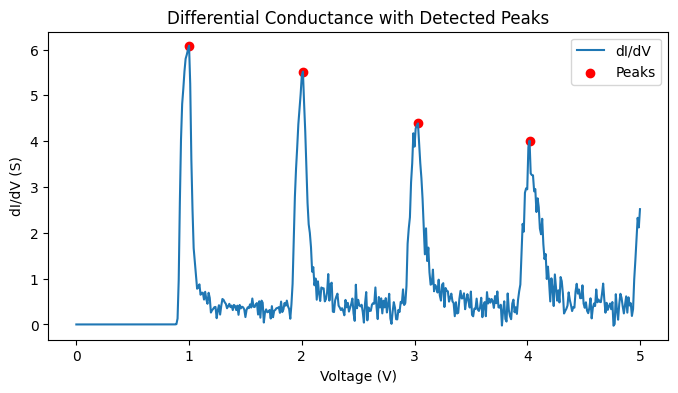

100  1  0.9850 V, G_high=6.083464 S
100  2  1.9750 V, G_high=5.517998 S
100  3  2.9750 V, G_high=4.387878 S
100  4  3.9450 V, G_high=4.012130 S


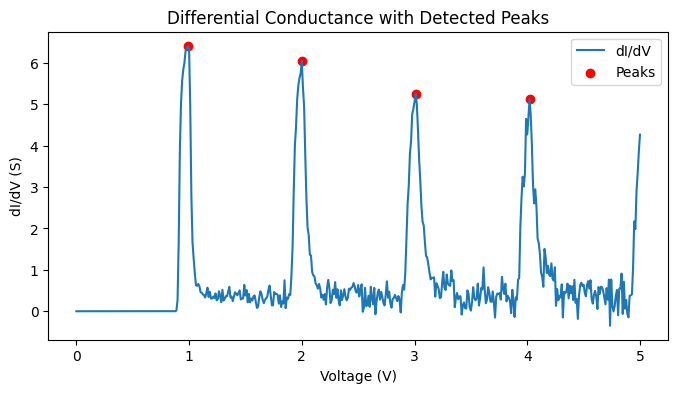

200  1  0.9750 V, G_high=6.417172 S
200  2  1.9650 V, G_high=6.046149 S
200  3  2.9550 V, G_high=5.258277 S
200  4  3.9450 V, G_high=5.129039 S


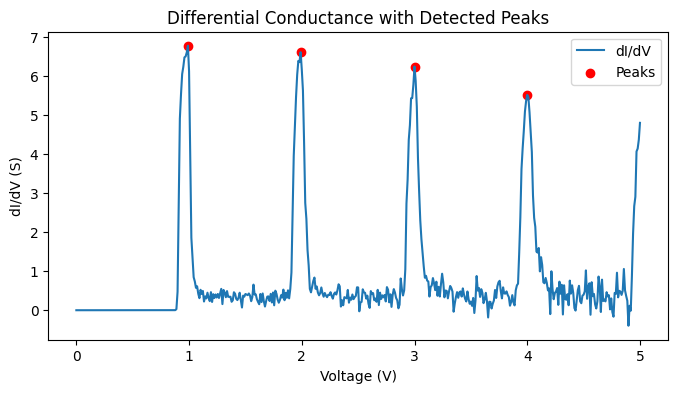

400  1  0.9750 V, G_high=6.782172 S
400  2  1.9550 V, G_high=6.615640 S
400  3  2.9450 V, G_high=6.248796 S
400  4  3.9250 V, G_high=5.522422 S


In [173]:
highconductance_values = np.full((4,4),np.nan)

print('=' * 65)
print(f'{"Gb":>6}  {"Step":>5}  {"V_step":>8}  {"G_high (dI/dV)":>16}')
print('=' * 65)

for idx, (Gb,V,I) in enumerate(zip(Gb_values,V_list,I_list)):

    steps = extract_step_properties(V, I, n_steps=4,prominence=0.5, distance = 5,averaging = 10, plotting = True)

    for s, (Vstep, Ghigh, Glow) in enumerate(steps):
        highconductance_values[idx, s] = Ghigh
        print(f'{Gb}  {s+1}  {Vstep:.4f} V, G_high={Ghigh:.6f} S')

print(65*'=')

In [ ]:
def scaling_law(Gb, G0, exponent):
    return G0 * (Gb)**exponent

print('Scaling of high conductance with Gb:')
print()

exps = []
# Numerical check: ratio G_high(2*Gb) / G_high(Gb) for step 1
for i in range(4):
    print("="*65)
    print(f'Checking scaling for step {i+1}:')
    G_high_50 = highconductance_values[0, i]
    G_high_100 = highconductance_values[1, i]
    G_high_200 = highconductance_values[2, i]
    G_high_400 = highconductance_values[3, i]
    List = np.array([G_high_50, G_high_100, G_high_200, G_high_400])
    popt, _ = curve_fit(scaling_law, Gb_values, List, p0=[1e-6, 1.0])
    G0, exponent = popt
    # plt.plot(Gb_values, List, 'o', label='Data')
    # Gb_fit = np.linspace(min(Gb_values), max(Gb_values), 100)
    # plt.plot(Gb_fit, scaling_law(Gb_fit, *popt), '-', label=f'Fit: G0={G0:.2e}, exp={exponent:.2f}')
    # plt.xlabel('Gb (S)')
    # plt.ylabel('G_high (S)')
    # plt.title(f'Scaling of G_high with Gb for step {i+1}')
    # plt.legend()
    # plt.show()
    ratio_100_50  = G_high_100 / G_high_50
    ratio_200_100 = G_high_200 / G_high_100
    ratio_400_200 = G_high_400 / G_high_200
    
    print(f'  G_high(100)/G_high(50)  = {ratio_100_50:.3f} ')
    print(f'  G_high(200)/G_high(100) = {ratio_200_100:.3f} ')
    print(f'  G_high(400)/G_high(200) = {ratio_400_200:.3f} ')
    print(f'  Fitted exponent = {exponent:.3f} ')
    exps.append(exponent)
print("="*65)
print(f'Mean exponent = {np.mean(exps):.3f}+{np.std(exps):.3f}')


Scaling of high conductance with Gb:

Checking scaling for step 1:
  G_high(100)/G_high(50)  = 1.094 
  G_high(200)/G_high(100) = 1.055 
  G_high(400)/G_high(200) = 1.057 
  Fitted exponent = 0.092 
Checking scaling for step 2:
  G_high(100)/G_high(50)  = 1.312 
  G_high(200)/G_high(100) = 1.096 
  G_high(400)/G_high(200) = 1.094 
  Fitted exponent = 0.194 
Checking scaling for step 3:
  G_high(100)/G_high(50)  = 1.272 
  G_high(200)/G_high(100) = 1.198 
  G_high(400)/G_high(200) = 1.188 
  Fitted exponent = 0.276 
Checking scaling for step 4:
  G_high(100)/G_high(50)  = 1.345 
  G_high(200)/G_high(100) = 1.278 
  G_high(400)/G_high(200) = 1.077 
  Fitted exponent = 0.276 


## b) Dependence on induced charge q₂

We fix Gb = 100, Gs = 1, and scan q₂ ∈ (−0.5, 0.5) with q₁ = 0 (and
separately q₁ = 0.5).  For each q₂ we determine the step position,
high conductance and low conductance for steps 1, 2, and 3.

In [46]:
#Testing what is optimal
q1 = 0.5
q2 = 0
results_b = {} 
Numsteps = 1000
timeinterval = 1500
Vmax = 4
V, I = run_iv_curve(q1=q1, q2=q2, Numsteps=Numsteps, timeinterval=timeinterval, Vmax = Vmax)

Example I-V curve for q1=0.500 at q2=0.000:


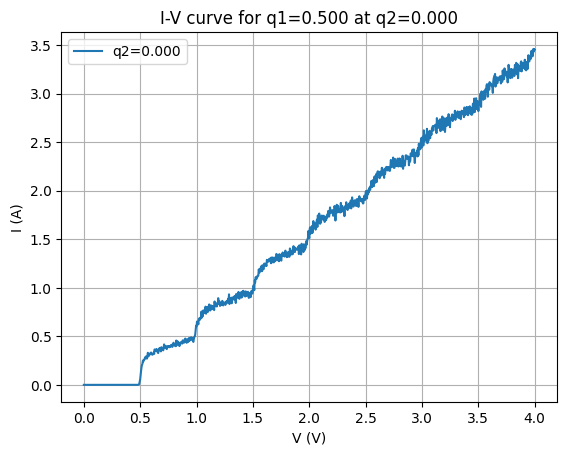

In [47]:
print(f'Example I-V curve for q1={q1:.3f} at q2={q2:.3f}:')
plt.plot(V, I, label=f'q2={q2:.3f}')
plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.title(f'I-V curve for q1={q1:.3f} at q2={q2:.3f}')
plt.grid(True)
plt.legend()
plt.show()

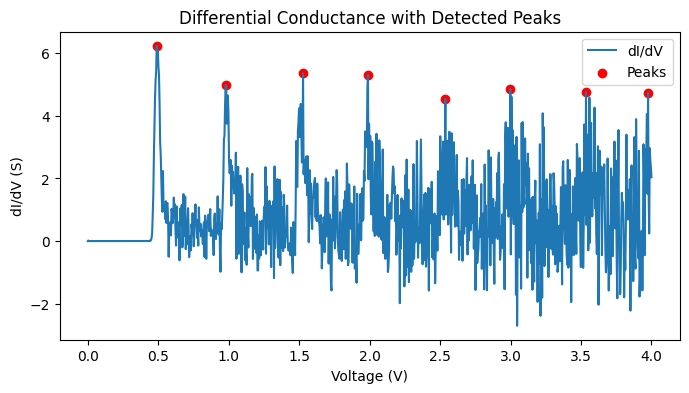

Extracted step properties for q1=0.500 at q2=-0.490:
  Step 1: V_step=0.4860 V, G_high=6.239207 S, G_low=-0.981105 S
  Step 2: V_step=0.9740 V, G_high=4.981720 S, G_low=-1.182822 S
  Step 3: V_step=1.5140 V, G_high=5.353512 S, G_low=-1.578873 S


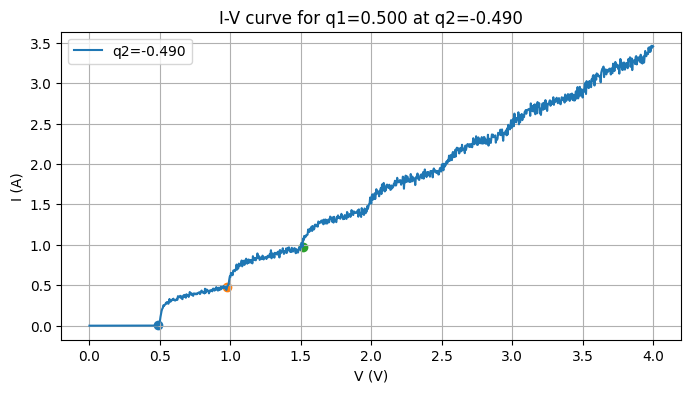

In [50]:
data = np.full((3,3),np.nan)
steps = extract_step_properties(V, I, n_steps=3,prominence=0.5, distance = 100,averaging = 10, plotting = True)
Vmax = 4
stepsizeV = Vmax/Numsteps
for s, (Vstep, Ghigh, Glow) in enumerate(steps):
    data[s, 0] = Vstep
    data[s, 1] = Ghigh
    data[s, 2] = Glow

plt.figure(figsize=(8,4))
print(f'Extracted step properties for q1={q1:.3f} at q2={q2:.3f}:')
for s, (Vstep, Ghigh, Glow) in enumerate(steps):
    print(f'  Step {s+1}: V_step={Vstep:.4f} V, G_high={Ghigh:.6f} S, G_low={Glow:.6f} S')
    index =int(np.round(Vstep/stepsizeV))
    plt.scatter(Vstep, I[index])

plt.plot(V, I, label=f'q2={q2:.3f}')

plt.xlabel('V (V)')
plt.ylabel('I (A)')
plt.title(f'I-V curve for q1={q1:.3f} at q2={q2:.3f}')
plt.grid(True)
plt.legend()
plt.show()

Scanning q2 for q1=0:   0%|          | 0/30 [00:00<?, ?it/s]

Example I-V curve for q1=0 at q2=-0.490:


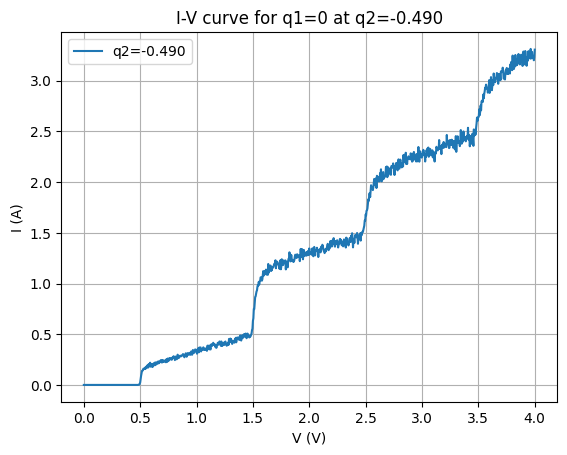

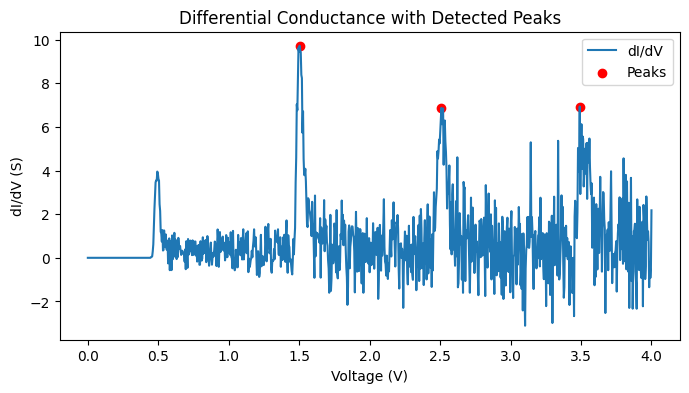

Scanning q2 for q1=0:   3%|▎         | 1/30 [00:45<21:58, 45.46s/it]

Extracted step properties for q1=0 at q2=-0.490:
  Step 1: V_step=1.4900 V, G_high=9.724857 S, G_low=-2.294838 S
  Step 2: V_step=2.4860 V, G_high=6.873321 S, G_low=-3.113828 S
  Step 3: V_step=3.4580 V, G_high=6.936270 S, G_low=-2.530414 S


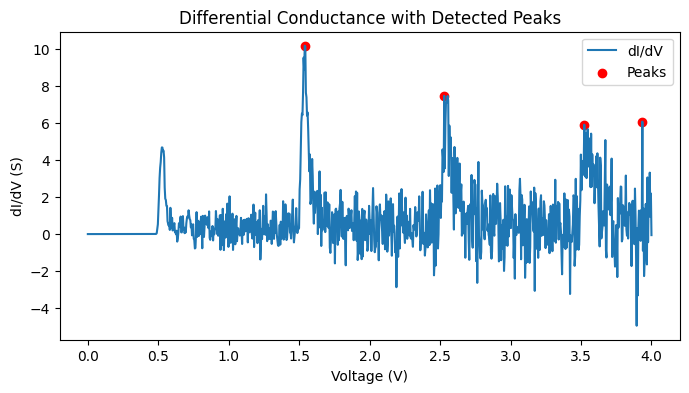

Scanning q2 for q1=0:   7%|▋         | 2/30 [01:31<21:20, 45.73s/it]

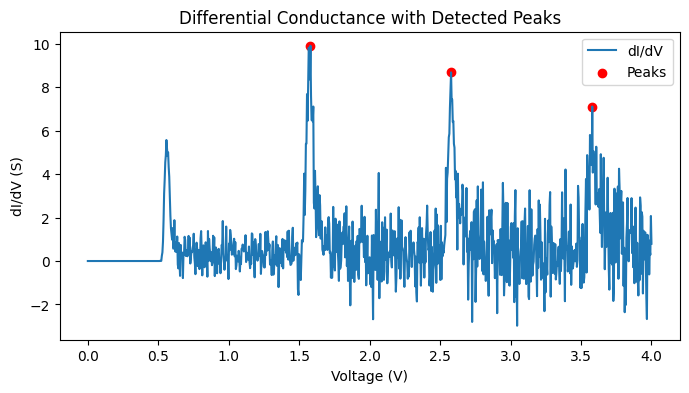

Scanning q2 for q1=0:  10%|█         | 3/30 [02:19<21:05, 46.87s/it]

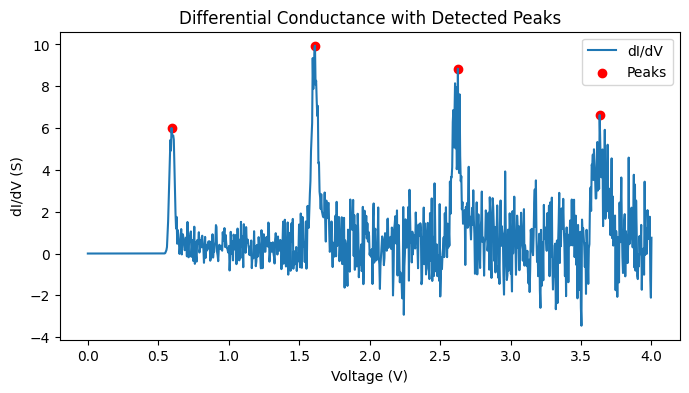

Scanning q2 for q1=0:  13%|█▎        | 4/30 [03:11<21:10, 48.87s/it]

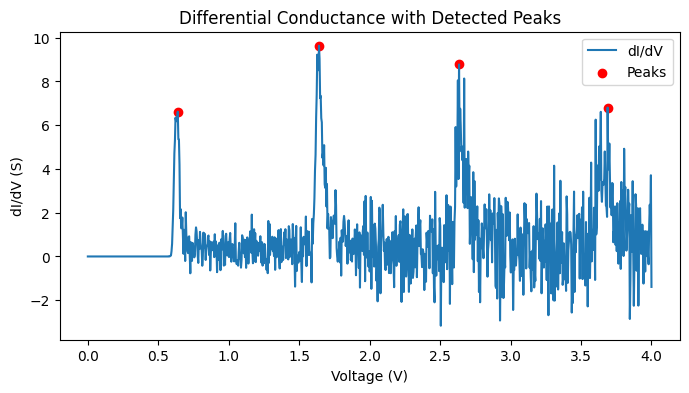

Scanning q2 for q1=0:  17%|█▋        | 5/30 [03:56<19:45, 47.43s/it]

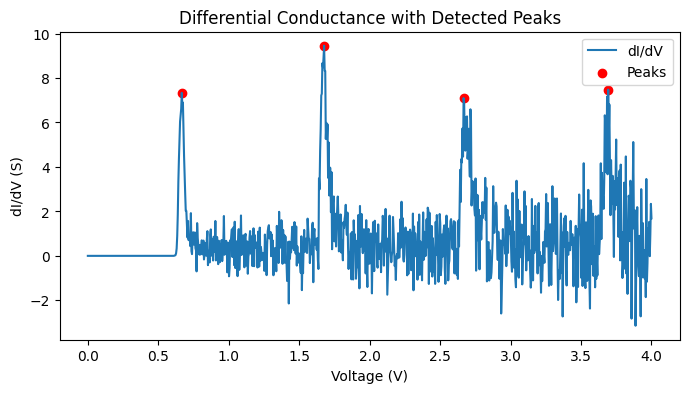

Scanning q2 for q1=0:  20%|██        | 6/30 [04:42<18:43, 46.82s/it]

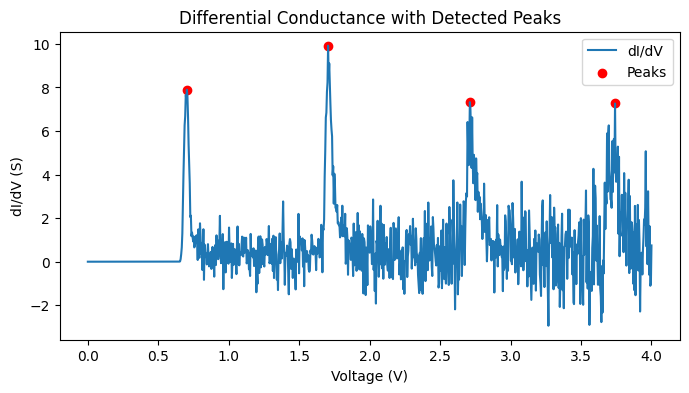

Scanning q2 for q1=0:  23%|██▎       | 7/30 [05:35<18:47, 49.03s/it]

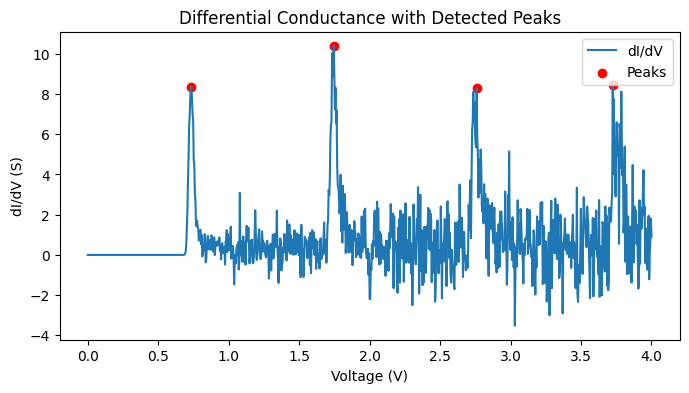

Scanning q2 for q1=0:  27%|██▋       | 8/30 [06:29<18:31, 50.53s/it]

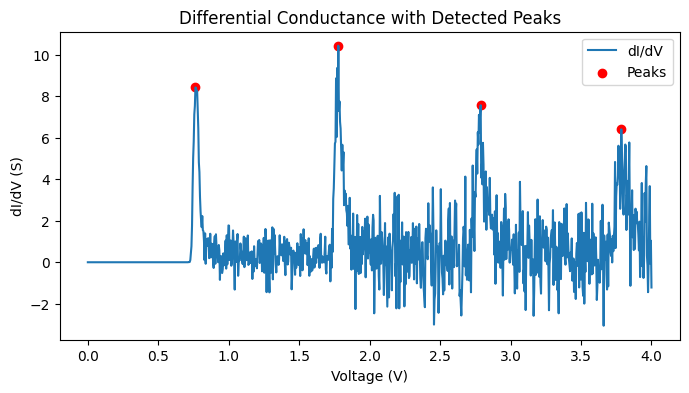

Scanning q2 for q1=0:  30%|███       | 9/30 [07:20<17:44, 50.69s/it]

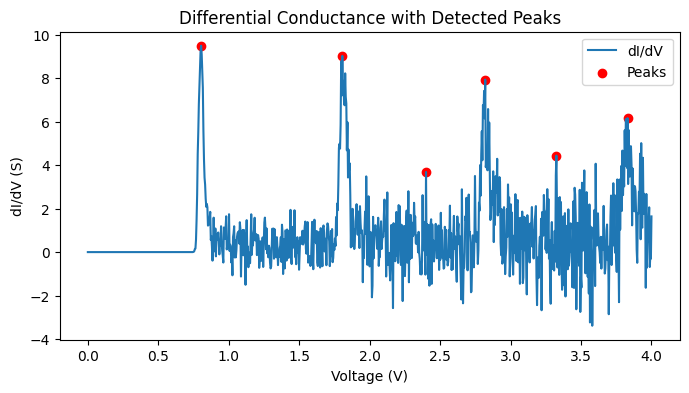

Scanning q2 for q1=0:  33%|███▎      | 10/30 [08:11<16:56, 50.82s/it]

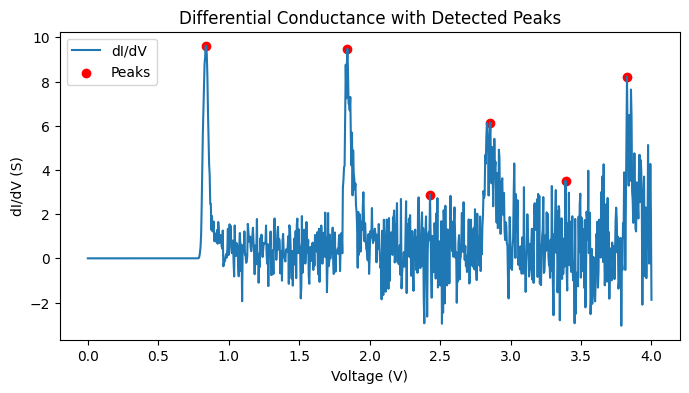

Scanning q2 for q1=0:  37%|███▋      | 11/30 [09:01<16:02, 50.65s/it]

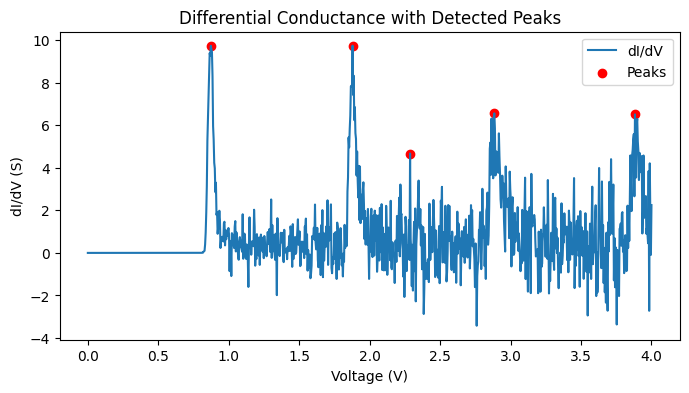

Scanning q2 for q1=0:  40%|████      | 12/30 [09:45<14:32, 48.47s/it]

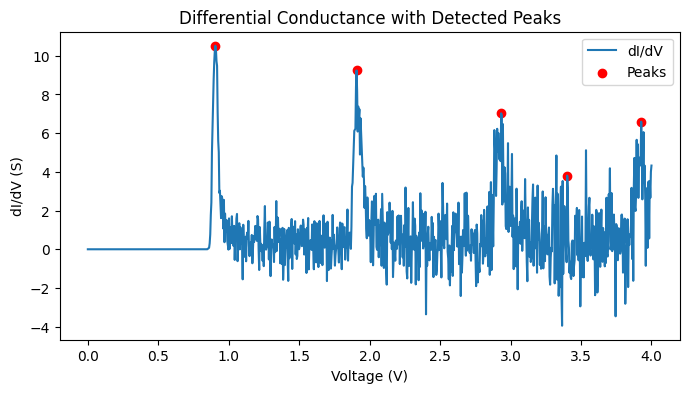

Scanning q2 for q1=0:  43%|████▎     | 13/30 [10:28<13:17, 46.94s/it]

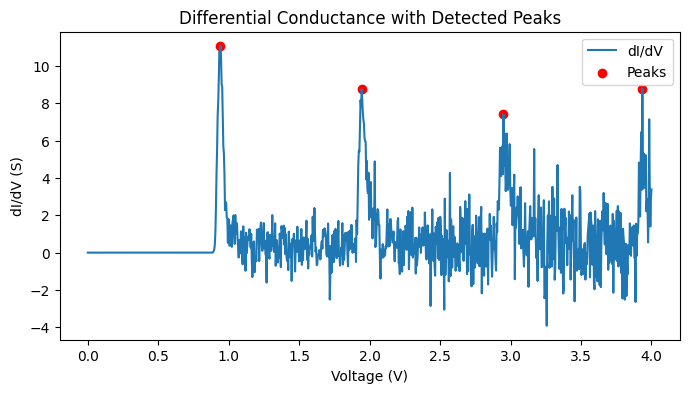

Scanning q2 for q1=0:  47%|████▋     | 14/30 [11:13<12:22, 46.43s/it]

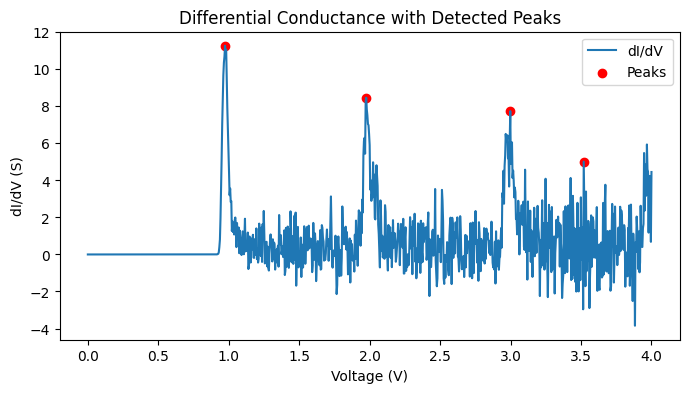

Scanning q2 for q1=0:  50%|█████     | 15/30 [12:00<11:38, 46.60s/it]

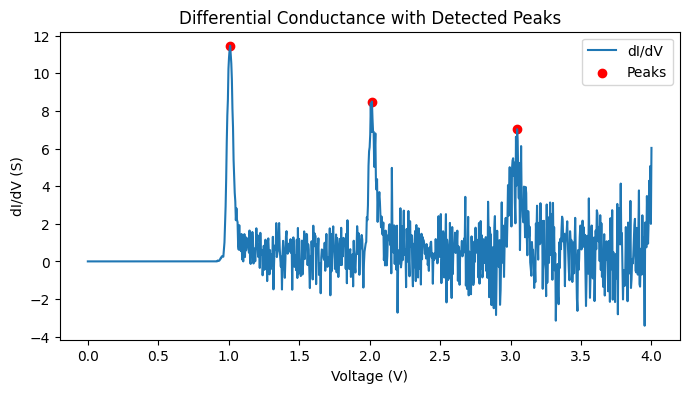

Scanning q2 for q1=0:  53%|█████▎    | 16/30 [12:50<11:04, 47.50s/it]

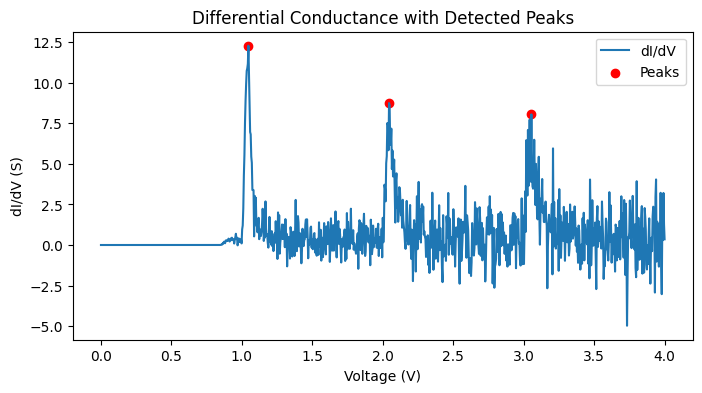

Scanning q2 for q1=0:  57%|█████▋    | 17/30 [13:40<10:27, 48.26s/it]

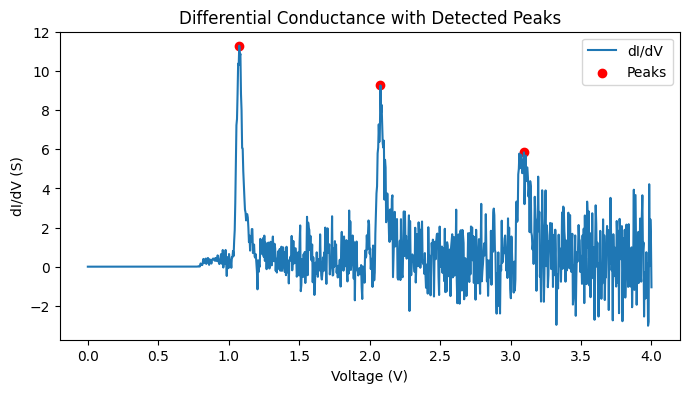

Scanning q2 for q1=0:  60%|██████    | 18/30 [14:31<09:47, 48.92s/it]

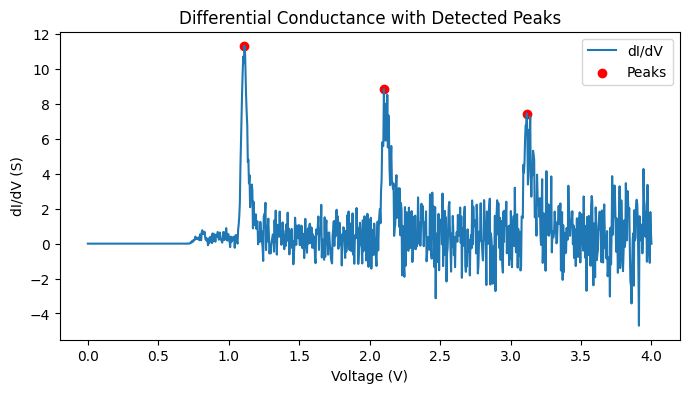

Scanning q2 for q1=0:  63%|██████▎   | 19/30 [15:21<09:03, 49.37s/it]

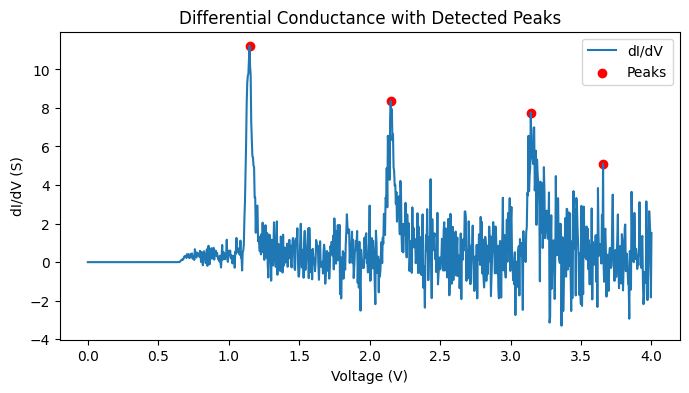

Scanning q2 for q1=0:  67%|██████▋   | 20/30 [16:09<08:10, 49.10s/it]

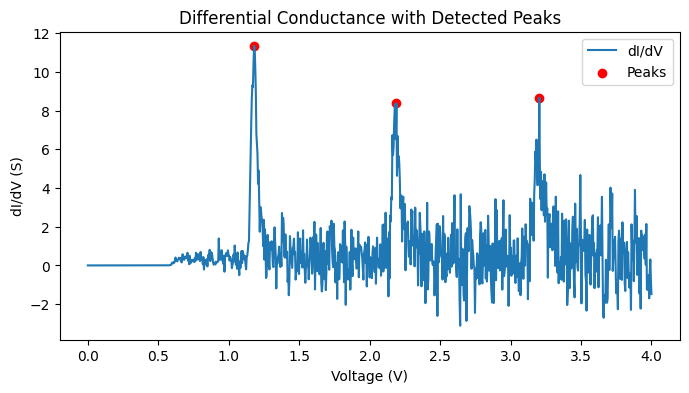

Scanning q2 for q1=0:  70%|███████   | 21/30 [16:57<07:18, 48.71s/it]

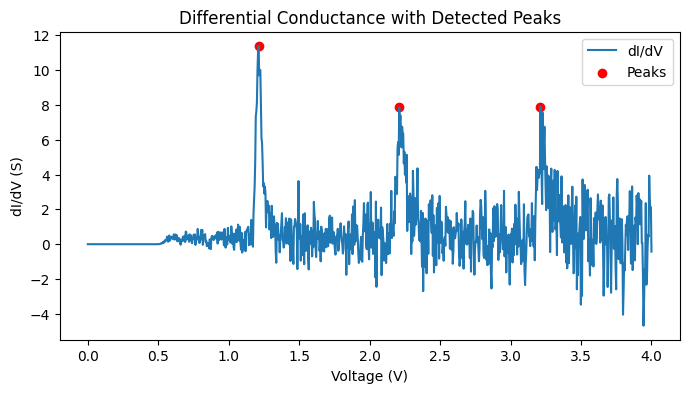

Scanning q2 for q1=0:  73%|███████▎  | 22/30 [17:45<06:27, 48.38s/it]

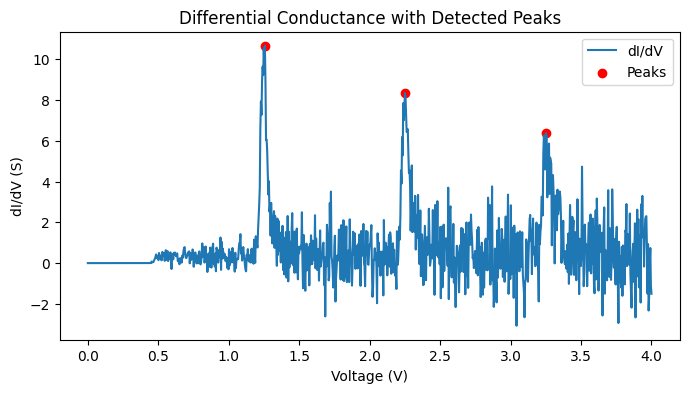

Scanning q2 for q1=0:  77%|███████▋  | 23/30 [18:33<05:37, 48.18s/it]

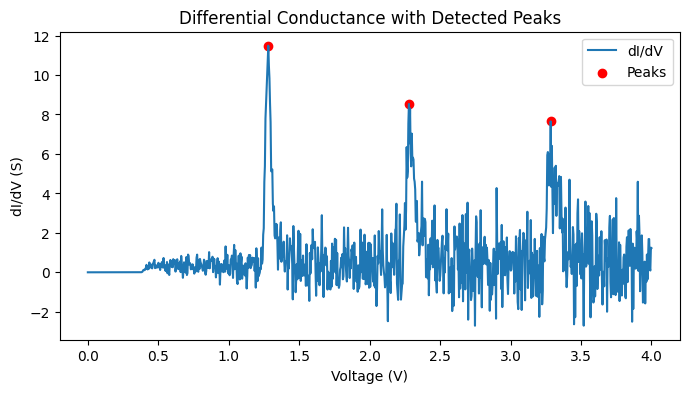

Scanning q2 for q1=0:  80%|████████  | 24/30 [19:21<04:48, 48.14s/it]

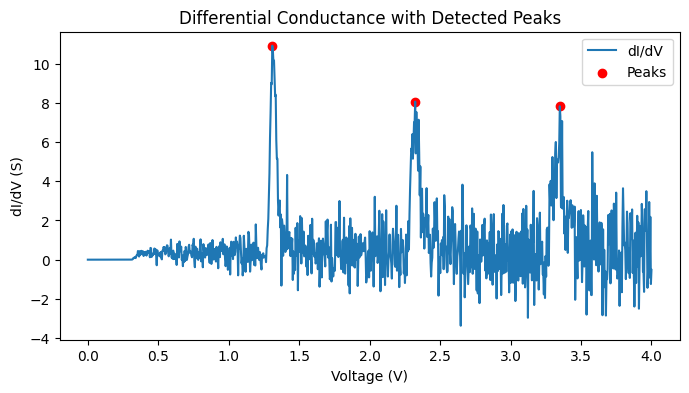

Scanning q2 for q1=0:  83%|████████▎ | 25/30 [20:08<04:00, 48.05s/it]

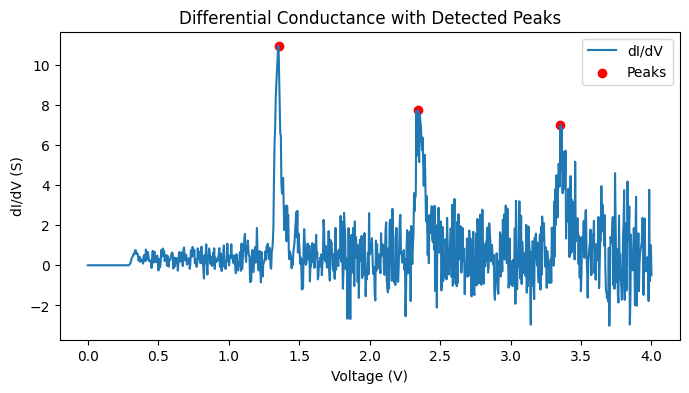

Scanning q2 for q1=0:  87%|████████▋ | 26/30 [20:57<03:13, 48.25s/it]

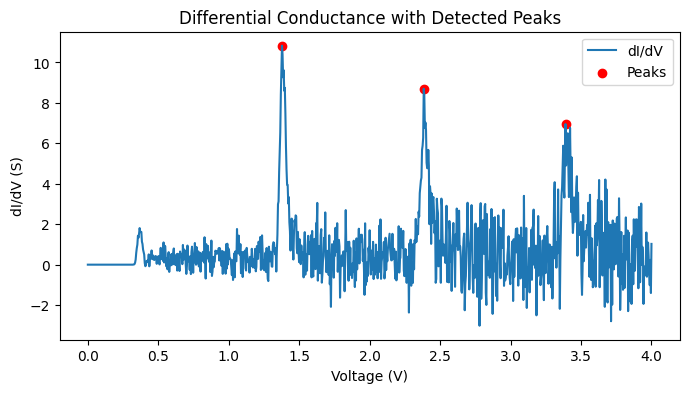

Scanning q2 for q1=0:  90%|█████████ | 27/30 [21:41<02:21, 47.07s/it]

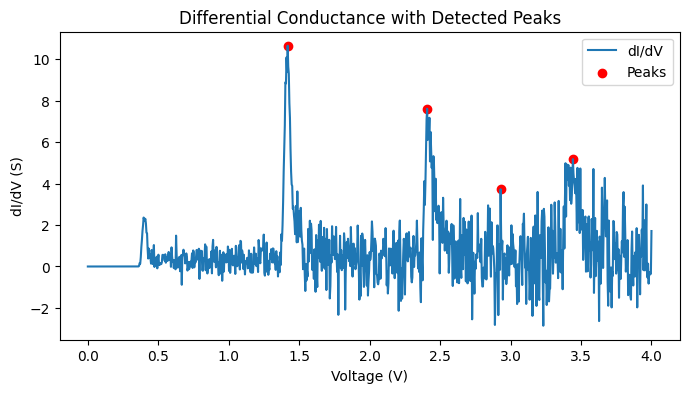

Scanning q2 for q1=0:  93%|█████████▎| 28/30 [22:26<01:32, 46.32s/it]

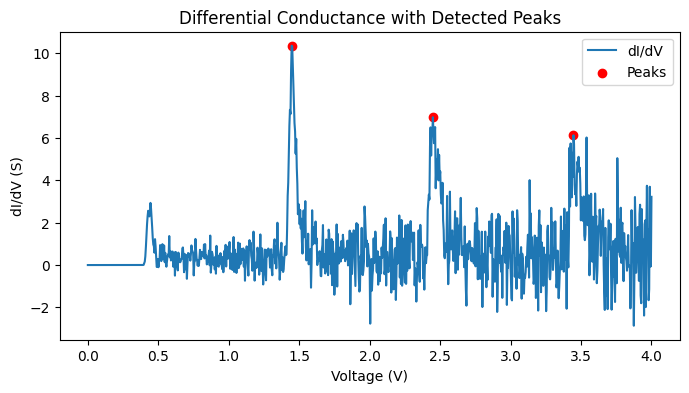

Scanning q2 for q1=0:  97%|█████████▋| 29/30 [23:10<00:45, 45.60s/it]

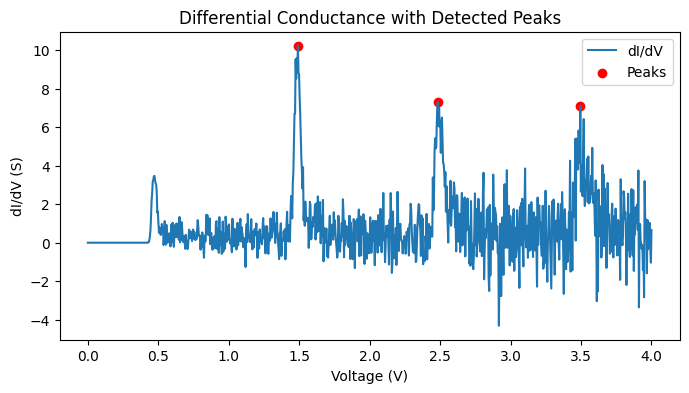

Scanning q2 for q1=0.5:   0%|          | 0/30 [00:00<?, ?it/s]

Example I-V curve for q1=0.5 at q2=-0.490:


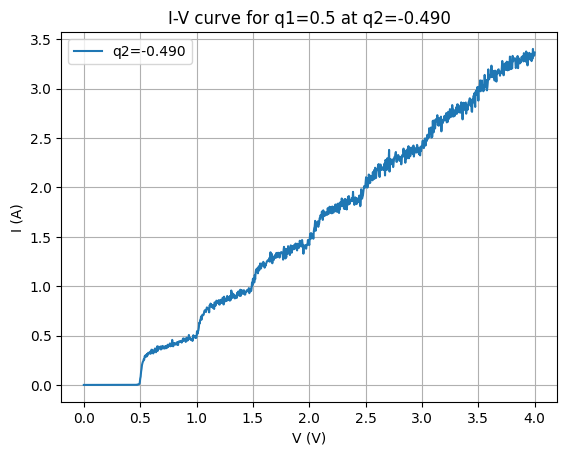

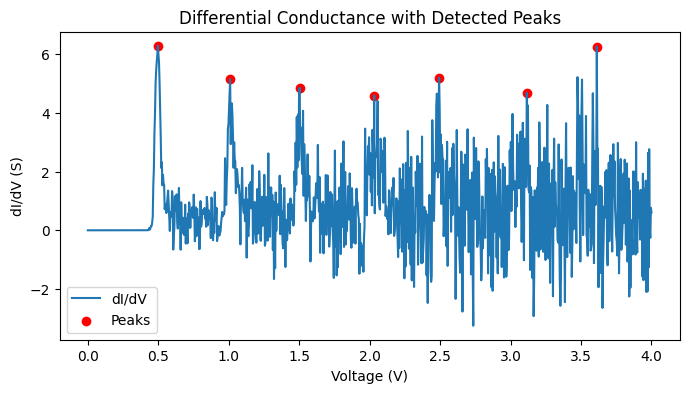

Scanning q2 for q1=0.5:   3%|▎         | 1/30 [00:53<26:01, 53.83s/it]

Extracted step properties for q1=0.5 at q2=-0.490:
  Step 1: V_step=0.4940 V, G_high=6.285869 S, G_low=-0.659923 S
  Step 2: V_step=1.0020 V, G_high=5.147617 S, G_low=-1.659019 S
  Step 3: V_step=1.4900 V, G_high=4.853120 S, G_low=-1.621110 S


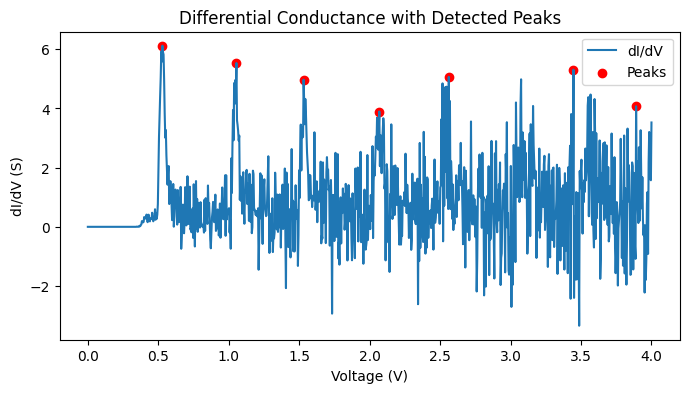

Scanning q2 for q1=0.5:   7%|▋         | 2/30 [01:45<24:37, 52.78s/it]

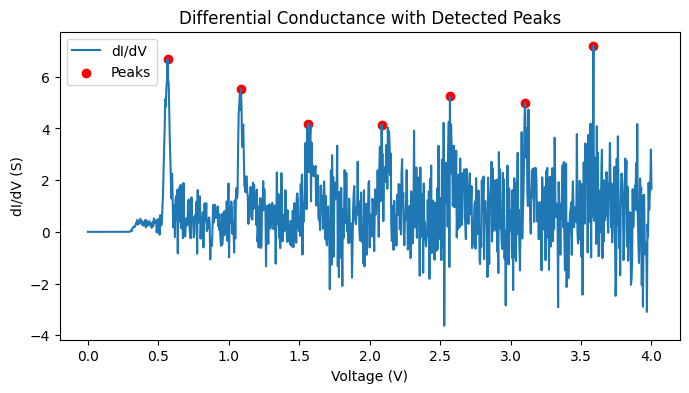

Scanning q2 for q1=0.5:  10%|█         | 3/30 [02:38<23:39, 52.59s/it]

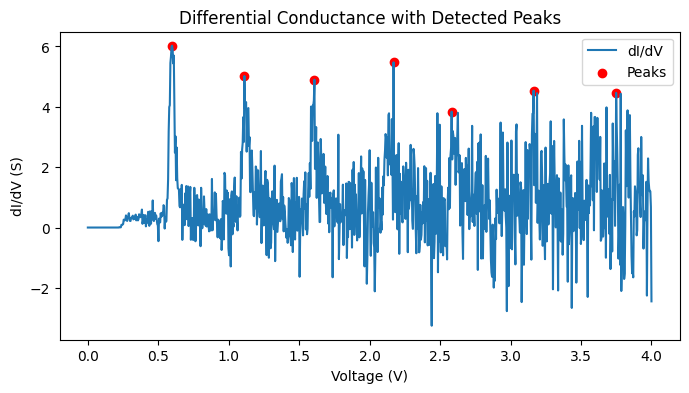

Scanning q2 for q1=0.5:  13%|█▎        | 4/30 [03:34<23:24, 54.01s/it]

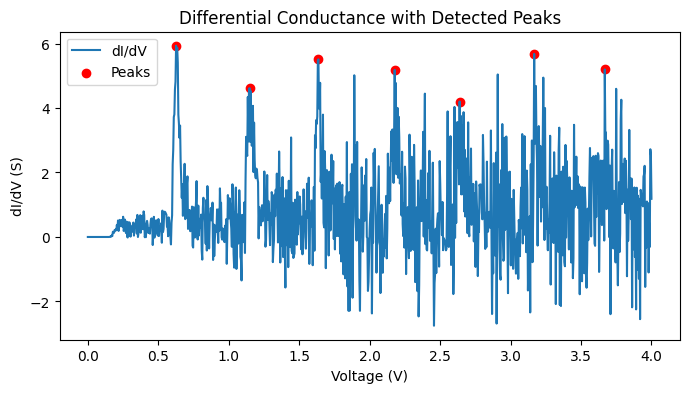

Scanning q2 for q1=0.5:  17%|█▋        | 5/30 [04:32<23:08, 55.53s/it]

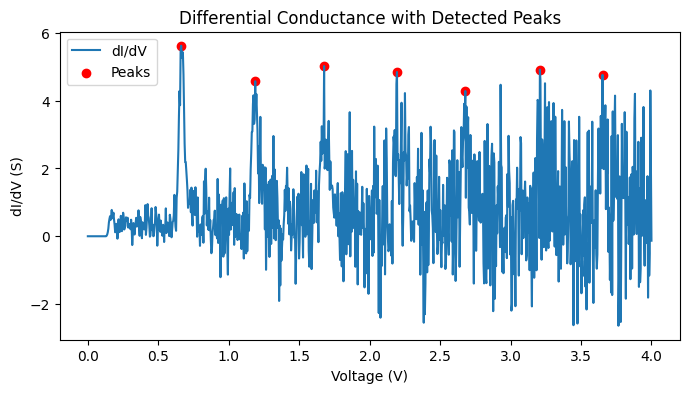

Scanning q2 for q1=0.5:  20%|██        | 6/30 [05:30<22:29, 56.23s/it]

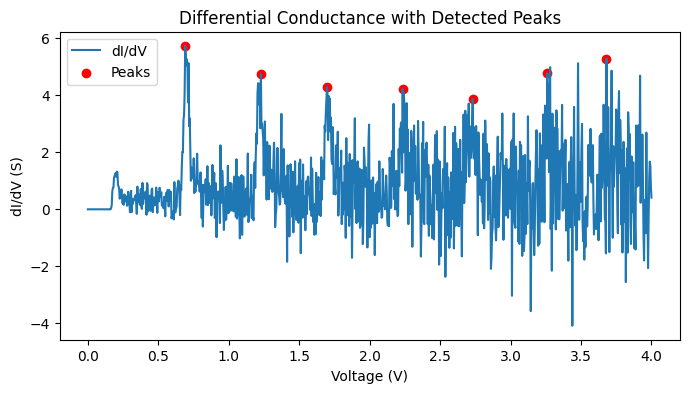

Scanning q2 for q1=0.5:  23%|██▎       | 7/30 [06:27<21:39, 56.50s/it]

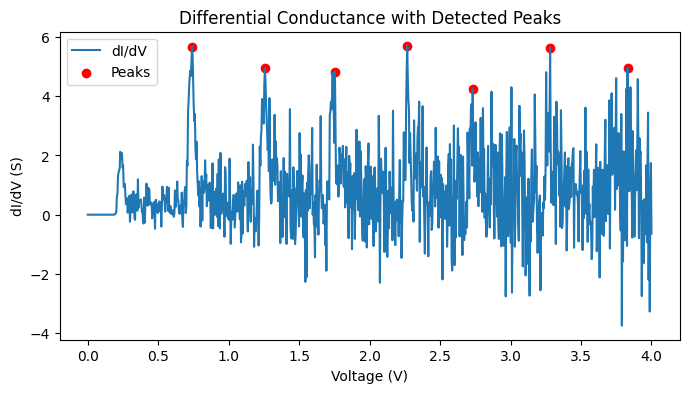

Scanning q2 for q1=0.5:  27%|██▋       | 8/30 [07:25<20:54, 57.01s/it]

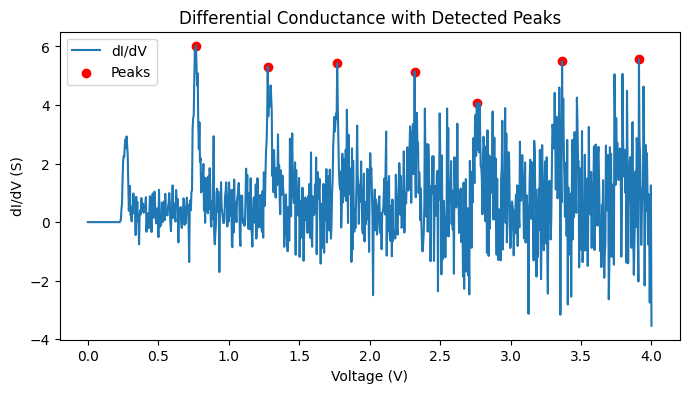

Scanning q2 for q1=0.5:  30%|███       | 9/30 [08:25<20:15, 57.89s/it]

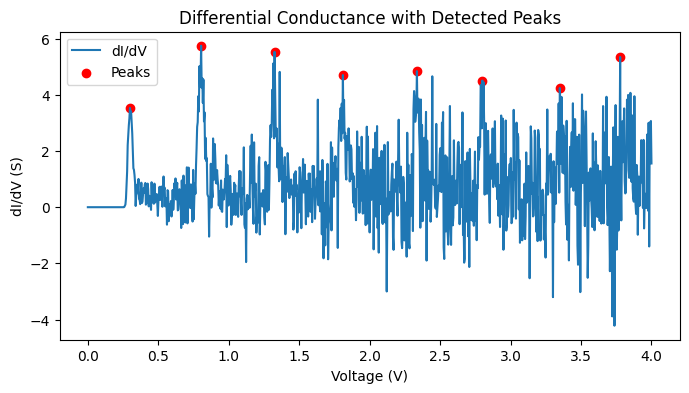

Scanning q2 for q1=0.5:  33%|███▎      | 10/30 [09:24<19:27, 58.37s/it]

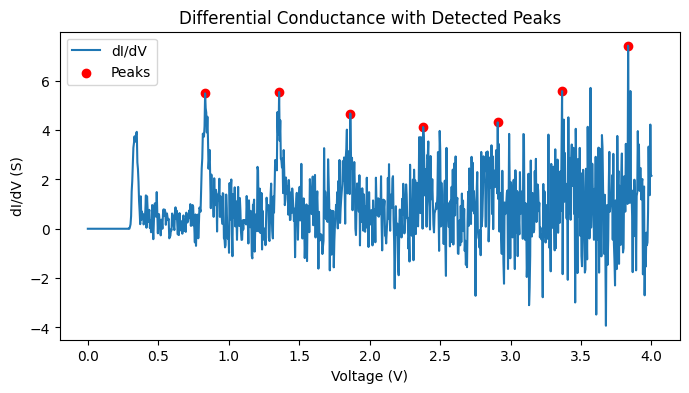

Scanning q2 for q1=0.5:  37%|███▋      | 11/30 [10:22<18:27, 58.31s/it]

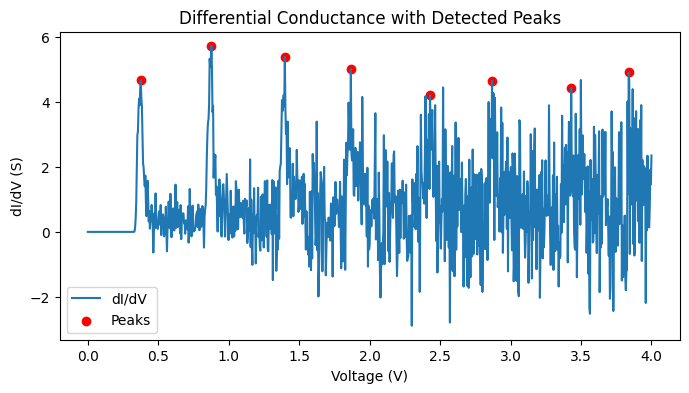

Scanning q2 for q1=0.5:  40%|████      | 12/30 [11:20<17:28, 58.25s/it]

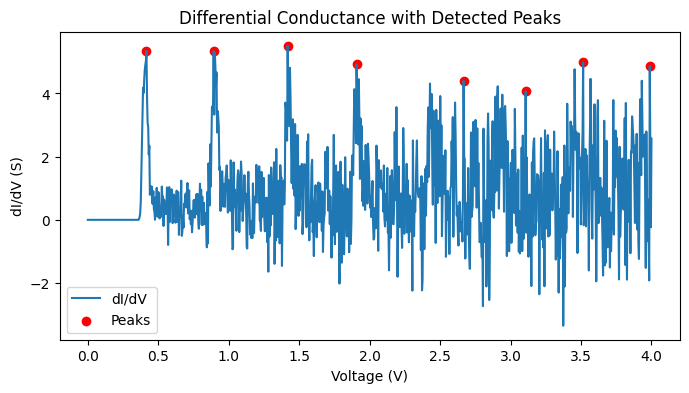

Scanning q2 for q1=0.5:  43%|████▎     | 13/30 [12:18<16:25, 57.98s/it]

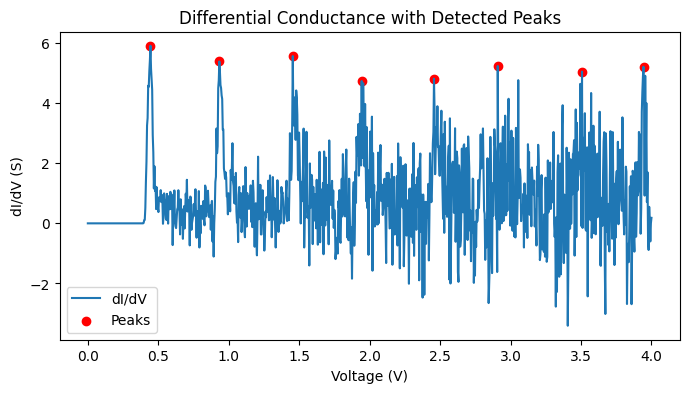

Scanning q2 for q1=0.5:  47%|████▋     | 14/30 [13:16<15:27, 57.95s/it]

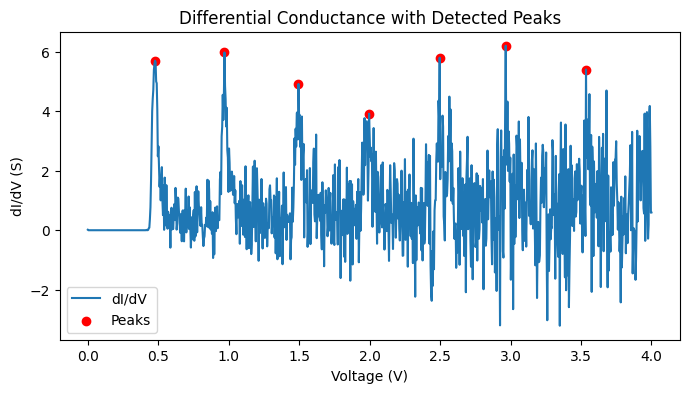

Scanning q2 for q1=0.5:  50%|█████     | 15/30 [14:14<14:30, 58.01s/it]

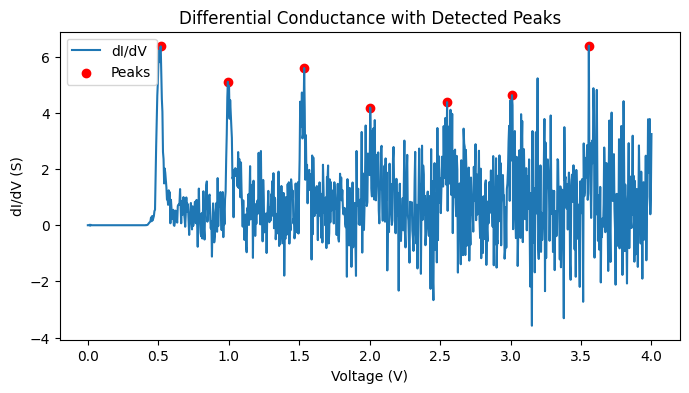

Scanning q2 for q1=0.5:  53%|█████▎    | 16/30 [15:12<13:31, 57.96s/it]

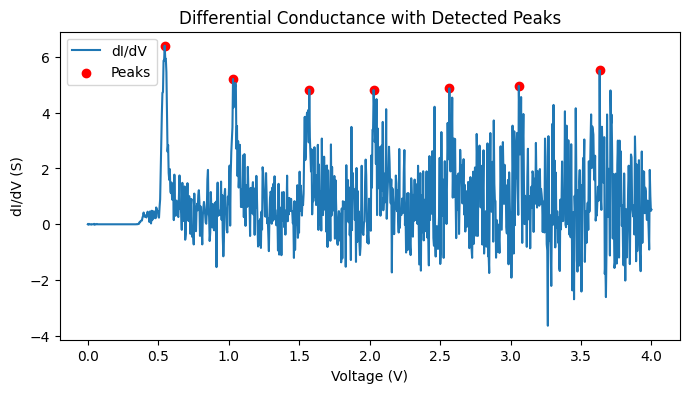

Scanning q2 for q1=0.5:  57%|█████▋    | 17/30 [16:10<12:34, 58.01s/it]

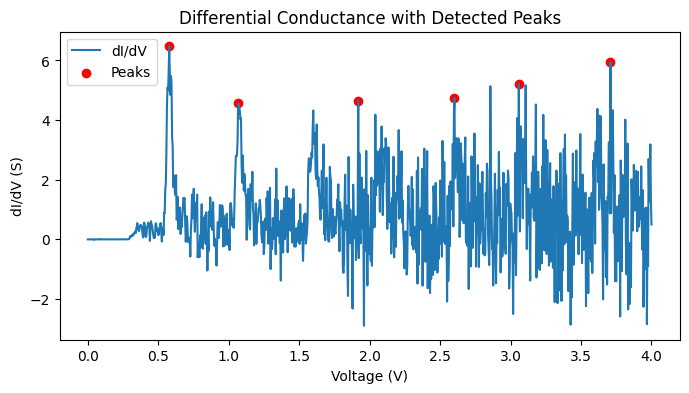

Scanning q2 for q1=0.5:  60%|██████    | 18/30 [17:08<11:35, 57.96s/it]

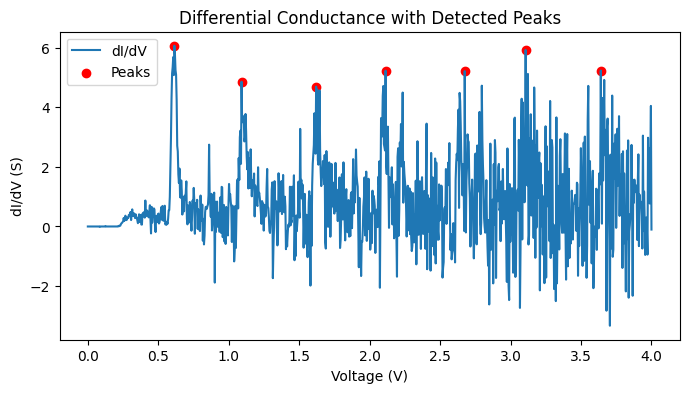

Scanning q2 for q1=0.5:  63%|██████▎   | 19/30 [18:06<10:37, 57.98s/it]

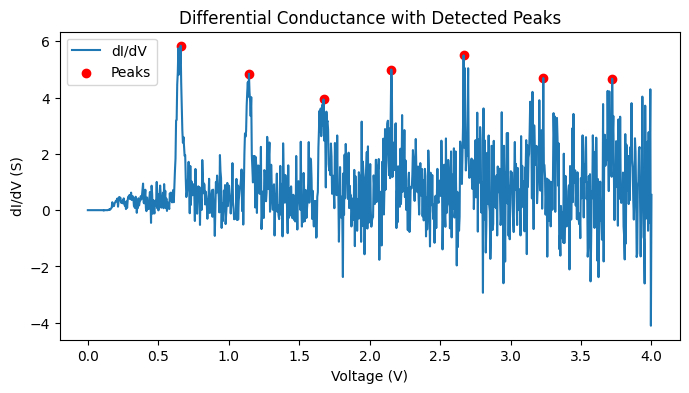

Scanning q2 for q1=0.5:  67%|██████▋   | 20/30 [19:04<09:40, 58.02s/it]

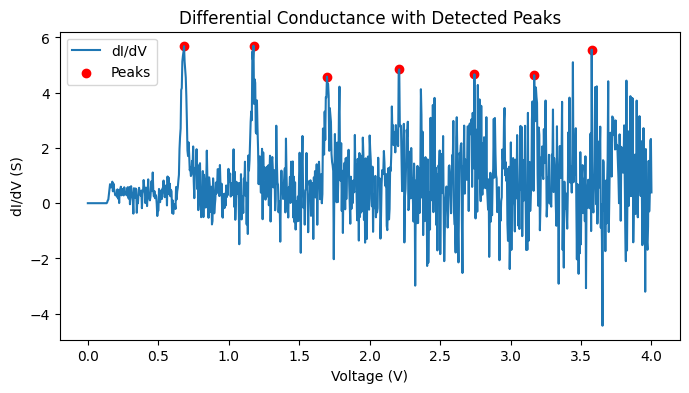

Scanning q2 for q1=0.5:  70%|███████   | 21/30 [20:02<08:41, 57.94s/it]

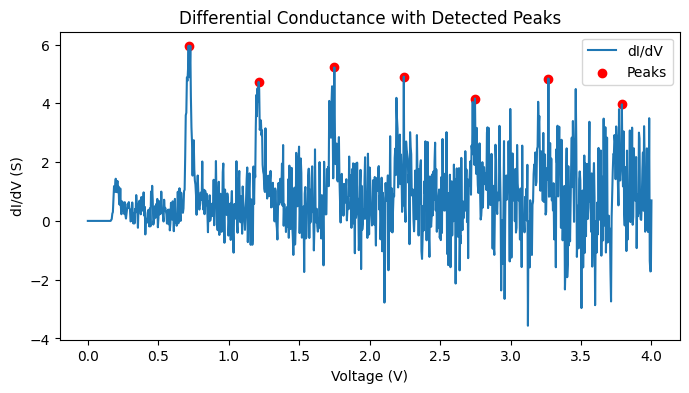

Scanning q2 for q1=0.5:  73%|███████▎  | 22/30 [20:59<07:43, 57.92s/it]

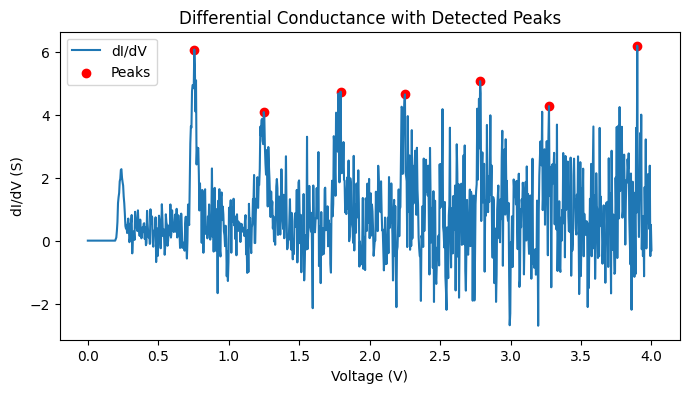

Scanning q2 for q1=0.5:  77%|███████▋  | 23/30 [21:57<06:45, 57.94s/it]

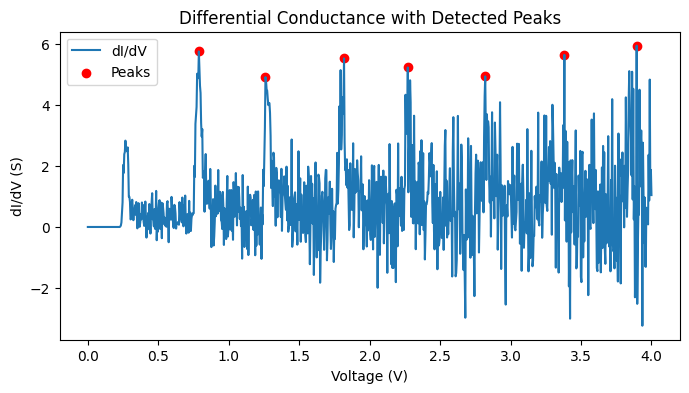

Scanning q2 for q1=0.5:  80%|████████  | 24/30 [22:55<05:47, 57.98s/it]

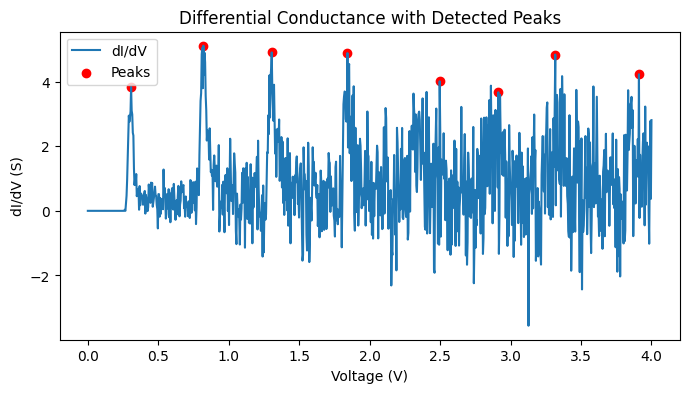

Scanning q2 for q1=0.5:  83%|████████▎ | 25/30 [23:54<04:50, 58.11s/it]

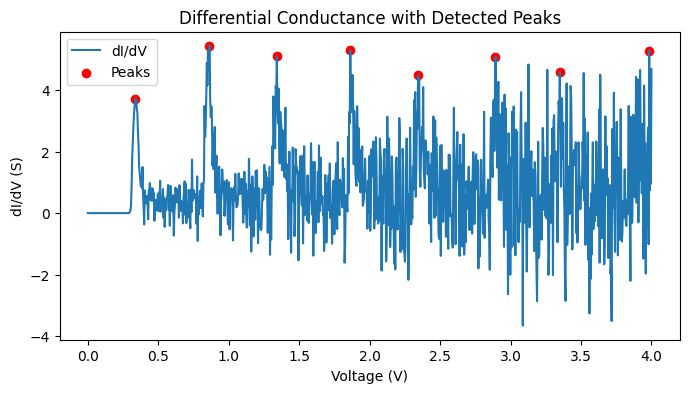

Scanning q2 for q1=0.5:  87%|████████▋ | 26/30 [24:52<03:51, 57.99s/it]

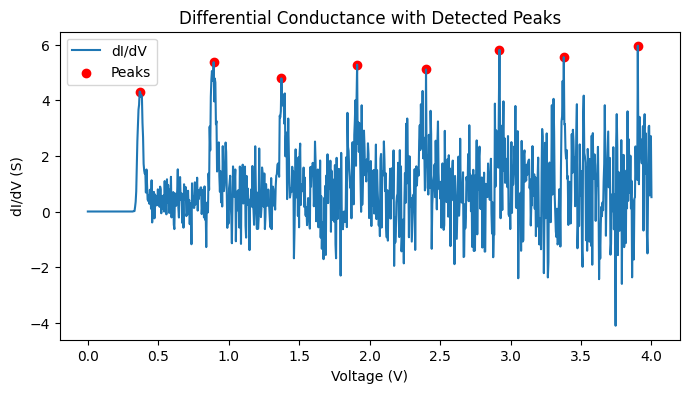

Scanning q2 for q1=0.5:  90%|█████████ | 27/30 [25:50<02:53, 57.98s/it]

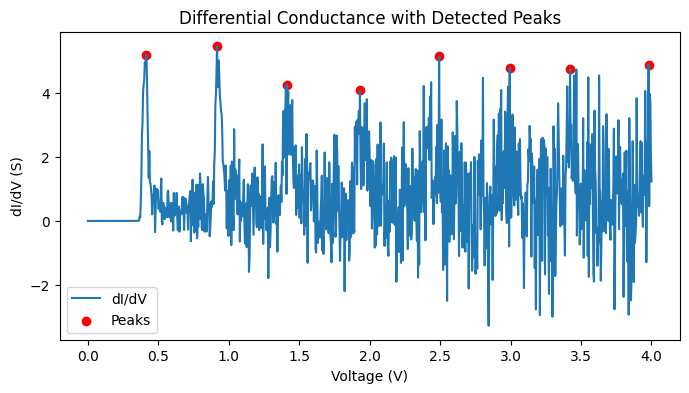

Scanning q2 for q1=0.5:  93%|█████████▎| 28/30 [26:48<01:56, 58.01s/it]

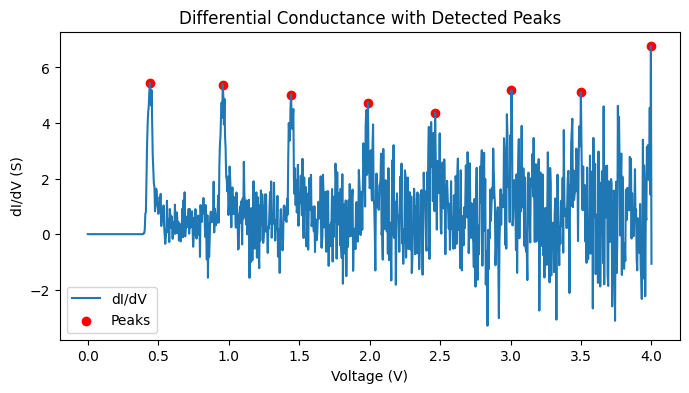

Scanning q2 for q1=0.5:  97%|█████████▋| 29/30 [27:46<00:57, 57.97s/it]

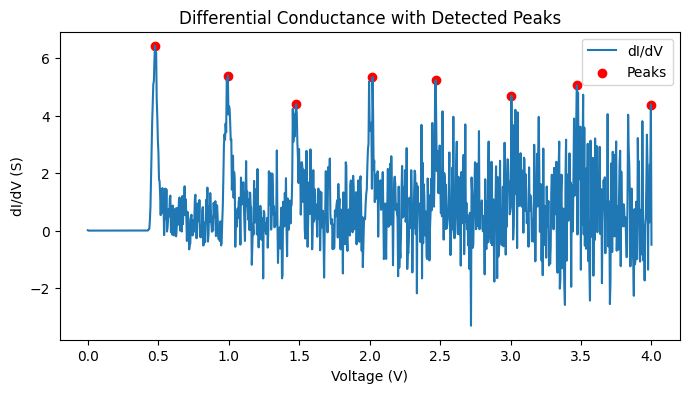

Scanning q2 for q1=0.5: 100%|██████████| 30/30 [28:43<00:00, 57.45s/it]

Part (b) data collection complete.


In [52]:
# --- Scan q2 for q1=0 and q1=0.5 ---
q2_values = np.linspace(-0.49, 0.49, 30)   # 30 points, avoid exactly ±0.5

Numsteps = 1000
timeinterval = 1500
Vmax = 4
results_b = {}   # (q1_label) -> array of shape (len(q2), 3, 3)
                 # dimensions: [q2_idx, step_idx, property_idx=(V,G_high,G_low)]

for q1_val, label in [(0.0, 'q1=0'), (0.5, 'q1=0.5')]:
    data = np.full((len(q2_values), 3, 3), np.nan)
    for i in tqdm.tqdm(range(len(q2_values)), desc=f'Scanning q2 for {label}'):
        q2 = q2_values[i]
        V, I = run_iv_curve(q1=q1_val, q2=q2, Numsteps=Numsteps, timeinterval=timeinterval, Vmax = Vmax)
        if i == 0: 
                print(f'Example I-V curve for {label} at q2={q2:.3f}:')
                plt.plot(V, I, label=f'q2={q2:.3f}')
                plt.xlabel('V (V)')
                plt.ylabel('I (A)')
                plt.title(f'I-V curve for {label} at q2={q2:.3f}')
                plt.grid(True)
                plt.legend()
                plt.show()
        steps = extract_step_properties(V, I, n_steps=3,prominence=0.6, distance = 100,averaging = 10, plotting = True)
        for s, (Vstep, Ghigh, Glow) in enumerate(steps):
            data[i, s, 0] = Vstep
            data[i, s, 1] = Ghigh
            data[i, s, 2] = Glow
        if i ==0:
            print(f'Extracted step properties for {label} at q2={q2:.3f}:')
            for s, (Vstep, Ghigh, Glow) in enumerate(steps):
                print(f'  Step {s+1}: V_step={Vstep:.4f} V, G_high={Ghigh:.6f} S, G_low={Glow:.6f} S')
        
    results_b[label] = data

np.savez('DataexerciseB', results_b=results_b, q2_values=q2_values)
print('Part (b) data collection complete.')

In [53]:
results_b = np.load('DataexerciseB.npz', allow_pickle=True)['results_b'].item()

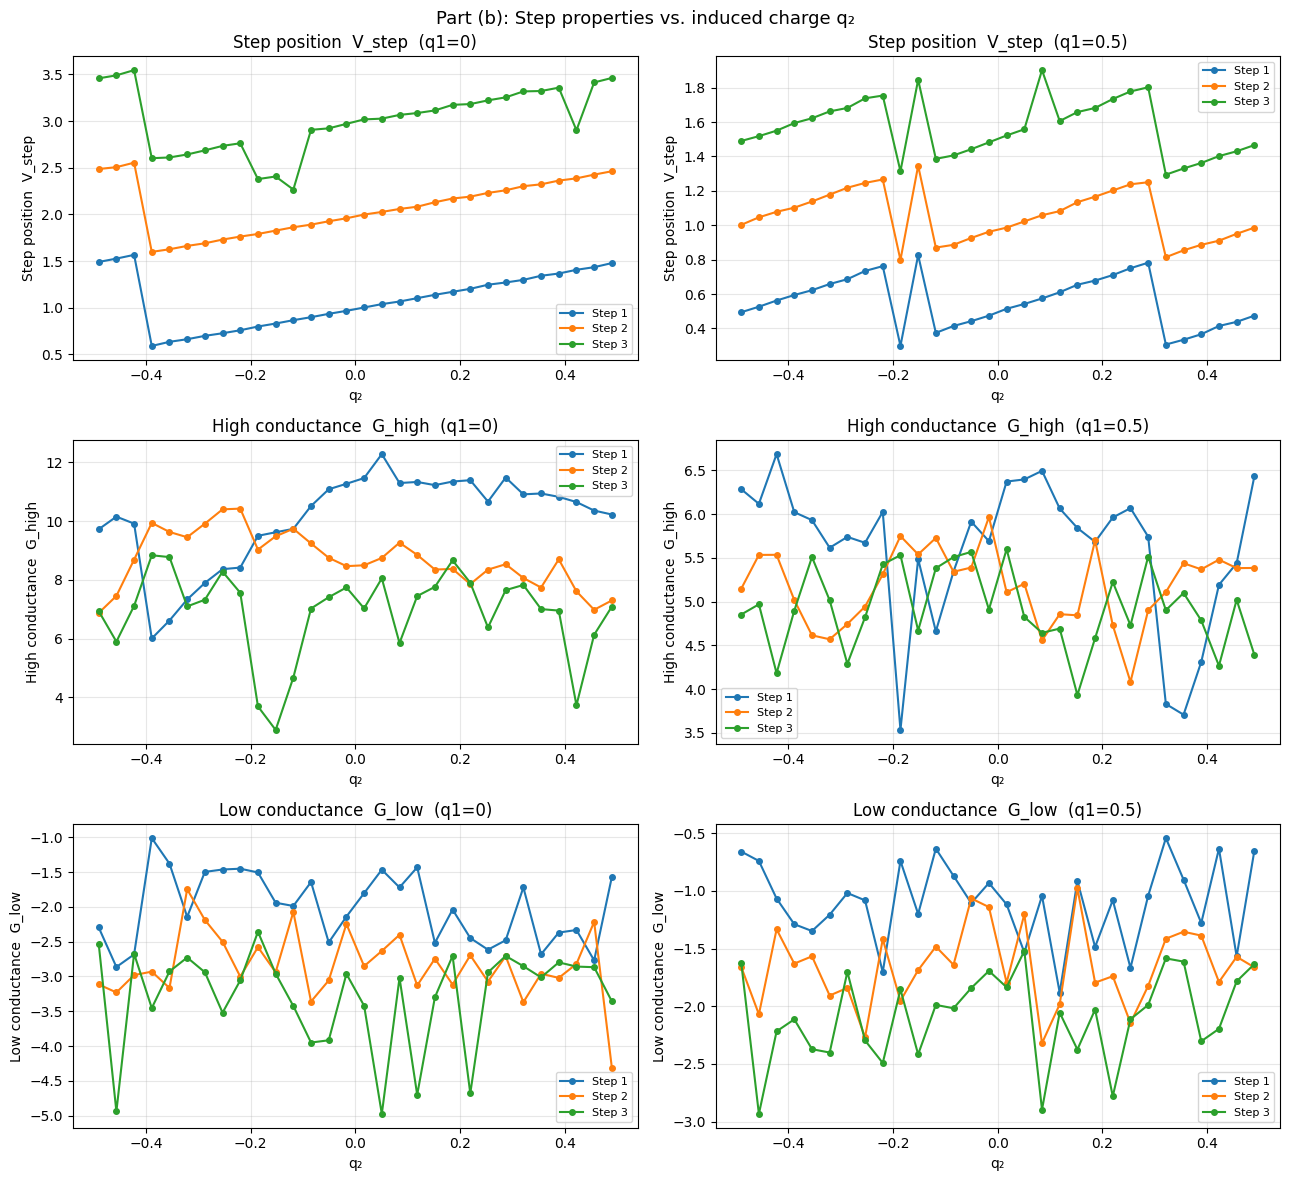

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
step_colors = ['tab:blue', 'tab:orange', 'tab:green']
step_labels = ['Step 1', 'Step 2', 'Step 3']
q1_labels   = ['q1=0', 'q1=0.5']

row_titles = ['Step position  V_step', 'High conductance  G_high', 'Low conductance  G_low']

for col, label in enumerate(q1_labels):
    data = results_b[label]
    for row, prop_name in enumerate(row_titles):
        ax = axes[row, col]
        for s in range(3):
            y = data[:, s, row]
            mask = ~np.isnan(y)
            ax.plot(q2_values[mask], y[mask],
                    color=step_colors[s], marker='o', ms=4,
                    label=step_labels[s])
        ax.set_xlabel('q₂')
        ax.set_ylabel(prop_name)
        ax.set_title(f'{prop_name}  ({label})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Part (b): Step properties vs. induced charge q₂', fontsize=13)
plt.tight_layout()
plt.show()

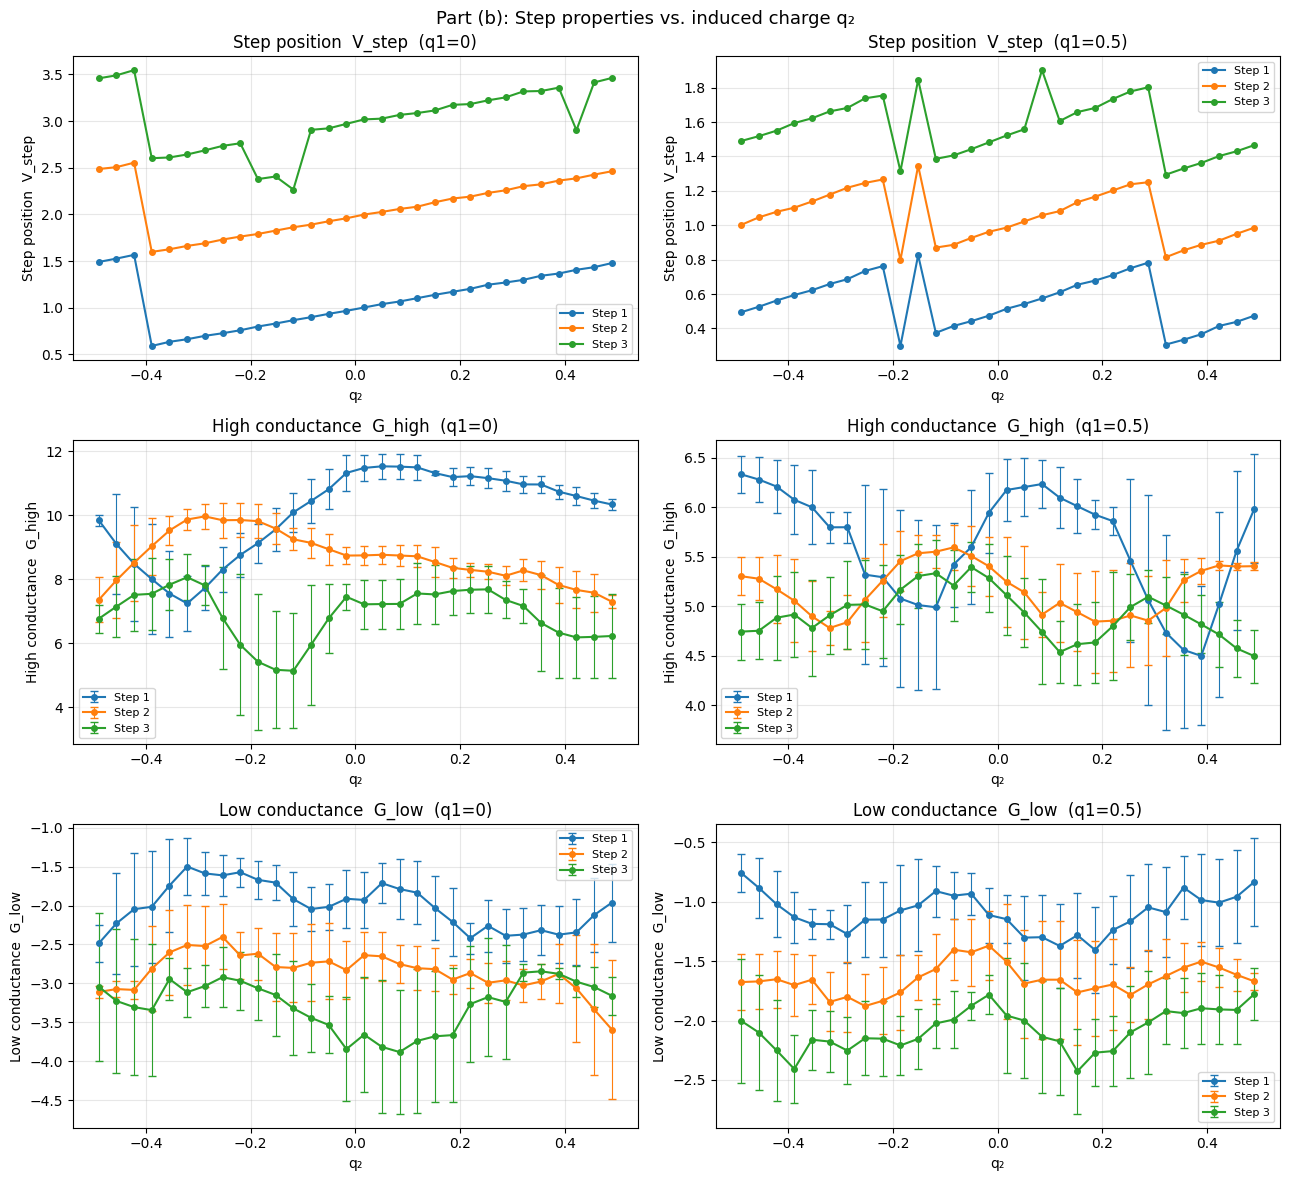

In [61]:
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
step_colors = ['tab:blue', 'tab:orange', 'tab:green']
step_labels = ['Step 1', 'Step 2', 'Step 3']
q1_labels   = ['q1=0', 'q1=0.5']

row_titles = ['Step position  V_step', 'High conductance  G_high', 'Low conductance  G_low']

WINDOW = 5  # convolution window size

for col, label in enumerate(q1_labels):
    data = results_b[label]
    for row, prop_name in enumerate(row_titles):
        ax = axes[row, col]
        for s in range(3):
            y = data[:, s, row]
            mask = ~np.isnan(y)
            x = q2_values[mask]
            y_clean = y[mask]

            if row == 0:
                # Step position: plot raw data, no convolution
                ax.plot(x, y_clean,
                        color=step_colors[s], marker='o', ms=4,
                        label=step_labels[s])
            else:
                # Conductance rows: convolve and add errorbars
                y_smooth = uniform_filter1d(y_clean, size=WINDOW, mode='nearest')

                # Compute std in each sliding window for errorbars
                half = WINDOW // 2
                y_pad = np.pad(y_clean, half, mode='edge')
                y_err = np.array([
                    y_pad[i:i + WINDOW].std()
                    for i in range(len(y_clean))
                ])

                ax.errorbar(x, y_smooth, yerr=y_err,
                            color=step_colors[s], marker='o', ms=4,
                            capsize=3, linewidth=1.5, elinewidth=0.8,
                            label=step_labels[s])

        ax.set_xlabel('q₂')
        ax.set_ylabel(prop_name)
        ax.set_title(f'{prop_name}  ({label})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Part (b): Step properties vs. induced charge q₂', fontsize=13)
plt.tight_layout()
plt.show()

## c) Temperature dependence of the I–V curve

We set Gb = 100, q₁ = q₂ = 0 and compute 10 temperatures in
T $\in (10^{-4}, 10^{-2})$. 

In [81]:
T_values = np.logspace(-4, -2, 12)   # 12 temperatures

# Voltage range: slightly wider than the first step to capture rounding
Vmax_c   = 1.5
Numsteps_c = 500
timeinterval_c = 3000
V_c = np.linspace(0, Vmax_c, Numsteps_c + 1)

voltages_c = []   # T -> voltage array
currents_c = []   # T -> current array

for T_val in tqdm.tqdm(T_values):
    V_tmp, I_tmp = run_iv_curve(Gb=100, q1=0, q2=0, T=T_val,
                                Vmax=Vmax_c, Numsteps=Numsteps_c,
                                timeinterval=timeinterval_c)
    voltages_c.append(V_tmp)
    currents_c.append(I_tmp)

np.savez('DataexerciseC', T_values=T_values, voltages_c=voltages_c, currents_c=currents_c)
print('Part (c) data collection complete.')

100%|██████████| 12/12 [01:35<00:00,  7.95s/it]

Part (c) data collection complete.


In [180]:
data = np.load('DataexerciseC.npz')
T_values = data['T_values']
voltages_c = data['voltages_c']
currents_c = data['currents_c']

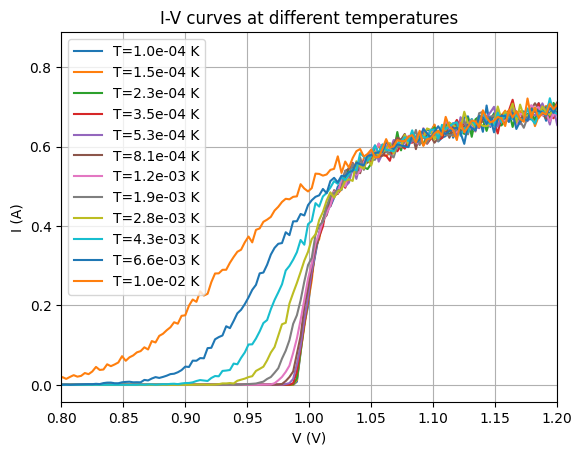

In [181]:
for idx, (T,V,I) in enumerate(zip(T_values,voltages_c,currents_c)):

    plt.plot(V, I, label=f'T={T:.1e} K')
    plt.xlabel('V (V)')
    plt.ylabel('I (A)')
    plt.title('I-V curves at different temperatures')
    plt.grid(True)
    plt.xlim(0.8, 1.2)
    plt.legend()
plt.show()

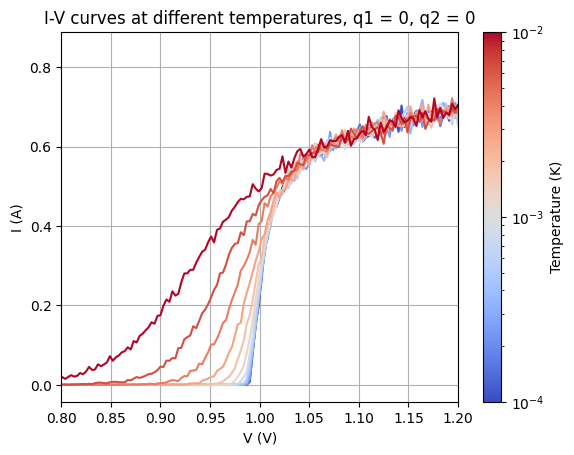

In [182]:
import matplotlib.colors as colors
import matplotlib.cm as cm

cmap = plt.colormaps['coolwarm']
norm = colors.LogNorm(vmin=min(T_values), vmax=max(T_values))

fig, ax = plt.subplots()

for T, V, I in zip(T_values, voltages_c, currents_c):
    ax.plot(V, I, color=cmap(norm(T)))

ax.set_xlabel('V (V)')
ax.set_ylabel('I (A)')
ax.set_title('I-V curves at different temperatures, q1 = 0, q2 = 0')
ax.grid(True)
ax.set_xlim(0.8, 1.2)

# Add colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature (K)')

plt.show()

More than one peak detected for T=6.6e-03 K. Only the first peak will be considered.
More than one peak detected for T=1.0e-02 K. Only the first peak will be considered.


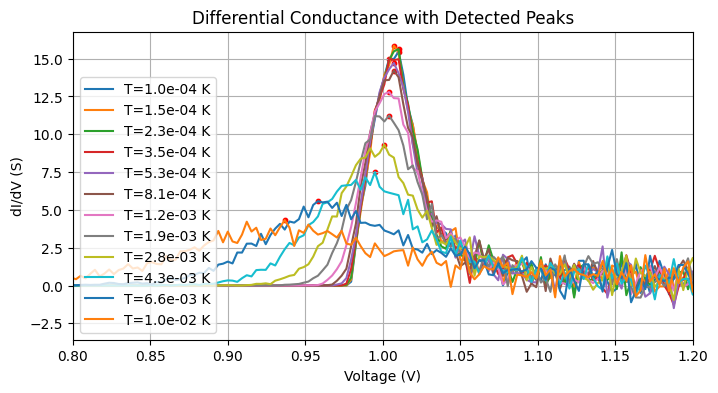

In [119]:
prominence = 0.6
distance=100
averaging = 10
plt.figure(figsize=(8,4))
peaks_list = []
for T, V, I in zip(T_values, voltages_c, currents_c):
    dV   = V[1] - V[0]
    dIdV = np.diff(I,n=1) / dV
    averaged_dIdV = np.convolve(dIdV, np.ones(averaging)/averaging, mode='valid')  # Simple moving average to smooth noise

    V_m  = 0.5 * (V[:-1] + V[1:])
    
    peaks, _ = find_peaks(averaged_dIdV, prominence=prominence * averaged_dIdV.max(), distance=distance)
    i = 0
    for p in peaks:
        i+= 1
        if i > 1:  # Only consider the first peak for this analysis
            print(f"More than one peak detected for T={T:.1e} K. Only the first peak will be considered.")
            break
        V_step = V_m[p]
        G_high = averaged_dIdV[p]
        peaks_list.append((V_step, G_high))
        
    plt.plot(np.linspace(V[0], V[-1], len(averaged_dIdV)), averaged_dIdV, label=f'T={T:.1e} K')
    plt.scatter(np.linspace(V[0], V[-1], len(averaged_dIdV))[peaks], averaged_dIdV[peaks], color='red',s=10)
    plt.xlabel('Voltage (V)')
    plt.ylabel('dI/dV (S)')
    plt.xlim(0.8, 1.2)
    plt.title('Differential Conductance with Detected Peaks')
    plt.grid(True)
    plt.legend(loc='lower left')
plt.show()

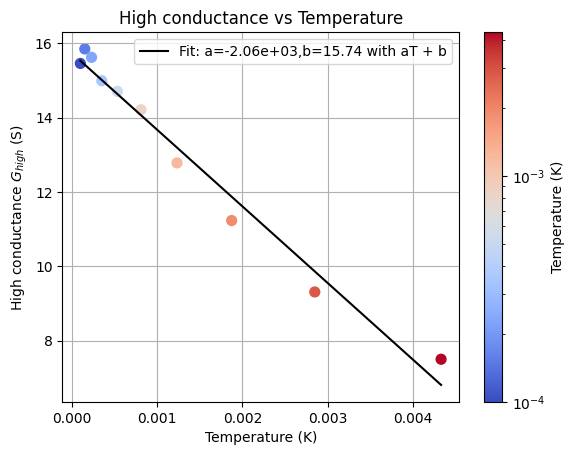

In [147]:

def scaling_law_temp(T, a, b):
    return a * T + b

till = 10

popt, _ = curve_fit(
    scaling_law_temp,
    T_values[:till],
    np.array(peaks_list)[:till, 1],
    p0=[1e6, 1.0]
)

a, b = popt

peaks_list = np.array(peaks_list)

# Colormap
cmap = plt.colormaps['coolwarm']
norm = colors.LogNorm(
    vmin=np.min(T_values[:till]),
    vmax=np.max(T_values[:till])
)

fig, ax = plt.subplots()

# Temperature-colored scatter
sc = ax.scatter(
    T_values[:till],
    peaks_list[:till, 1],
    c=T_values[:till],
    cmap=cmap,
    norm=norm,
    s=50
)

# Fit line
T_fit = np.linspace(
    np.min(T_values[:till]),
    np.max(T_values[:till]),
    500
)

ax.plot(
    T_fit,
    scaling_law_temp(T_fit, a, b),
    'k-',
    label=f'Fit: a={a:.2e},b={b:.2f} with aT + b'
)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('High conductance $G_{high}$ (S)')
ax.set_title('High conductance vs Temperature')
ax.grid(True)
ax.legend()

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Temperature (K)')

plt.show()

In [183]:
T_values = np.logspace(-4, 0, 12)   # 12 temperatures

# Voltage range: slightly wider than the first step to capture rounding
Vmax_c   = 4
Numsteps_c = 500
timeinterval_c = 2000
V_c = np.linspace(0, Vmax_c, Numsteps_c + 1)

voltages_c = []   # T -> voltage array
currents_c = []   # T -> current array

for T_val in tqdm.tqdm(T_values):
    V_tmp, I_tmp = run_iv_curve(Gb=100, q1=0, q2=0, T=T_val,
                                Vmax=Vmax_c, Numsteps=Numsteps_c,
                                timeinterval=timeinterval_c)
    voltages_c.append(V_tmp)
    currents_c.append(I_tmp)

np.savez('DataexerciseCpart2', T_values=T_values, voltages_c=voltages_c, currents_c=currents_c)
print('Part (c) part 2 data collection complete.')

  0%|          | 0/12 [00:00<?, ?it/s]c:\Users\meinh\Documents\Quantum Transport\Quantum_Transport\Coulomb blockade\simulator.py:96: RuntimeWarning: divide by zero encountered in scalar divide
  timeincrement=-np.log(np.random.rand())/arr[-1]
c:\Users\meinh\Documents\Quantum Transport\Quantum_Transport\Coulomb blockade\simulator.py:96: RuntimeWarning: overflow encountered in scalar divide
  timeincrement=-np.log(np.random.rand())/arr[-1]
 92%|█████████▏| 11/12 [31:57<02:54, 174.34s/it]


KeyboardInterrupt: 

In [184]:
np.savez('DataexerciseCpart2', T_values=T_values, voltages_c=voltages_c, currents_c=currents_c)
print('Part (c) part 2 data collection complete.')

Part (c) part 2 data collection complete.


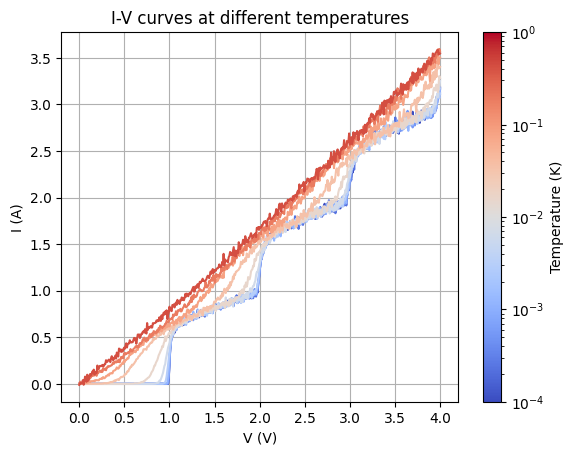

In [185]:
cmap = plt.colormaps['coolwarm']
norm = colors.LogNorm(vmin=min(T_values), vmax=max(T_values))

fig, ax = plt.subplots()

for T, V, I in zip(T_values, voltages_c, currents_c):
    ax.plot(V, I, color=cmap(norm(T)))

ax.set_xlabel('V (V)')
ax.set_ylabel('I (A)')
ax.set_title('I-V curves at different temperatures')
ax.grid(True)

# Add colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature (K)')

plt.show()

## d) How do the states evolve with voltage using CBSetup.sorted cache()? 

In [163]:
results_b = np.load('DataexerciseB.npz', allow_pickle=True)['results_b'].item()


In [164]:
delta_V = 0.05   # small voltage offset around the step

def get_cache_states(Gb, q1, q2, V_bias, T=1e-3, Cg=0.01,
                     timeinterval=10000, V_step=1.0):
    """
    Run a single-point simulation at V_bias (symmetric split: +V/2, -V/2)
    and return the sorted_cache contents.
    """
    Vg1 = q1 / Cg
    Vg2 = q2 / Cg
    Setup = setuptask9(Gb=100, Gs=1, C=1, Cg=0.01)
    Setup.temperature = T
    Setup.set_lead_voltage('LeadLeft',   V_bias / 2+ V_step/2)
    Setup.set_lead_voltage('LeadRight', -V_bias / 2- V_step/2)
    Setup.give_a_run()
    cache = Setup.sorted_cache()
    return cache

In [167]:
print('Identifying new charging states for each step (q1=0 and q1=0.5)\n')
print('=' * 70)

# for q1_val, label in [(0.0, 'q1=0'), (0.5, 'q1=0.5')]:
for q1_val, label in [(0.0, 'q1=0')]:  # Only q1=0 for now
    print(f'\n--- {label} ---')
    data = results_b[label]

    # Use a representative q2 value (e.g. q2=0.0 for q1=0, q2=0.1 for q1=0.5)
    q2_sample_values = [0]  # representative q2 values
    # q2_sample_values = q2_values[::7]   # every 7th point ≈ 5 representative values

    for q2 in q2_sample_values:
        # find index of q2 in q2_values
        idx = np.argmin(np.abs(q2_values - q2))

        print(f'  q2 = {q2:.3f}')
        for step_num in range(3):
            V_step = data[idx, step_num, 0]
            if np.isnan(V_step):
                print(f'    Step {step_num+1}: not detected')
                continue

            try:
                cache_before = get_cache_states(100, q1_val, q2, V_step - delta_V)
                cache_after  = get_cache_states(100, q1_val, q2, V_step + delta_V)

                print(f'    Step {step_num+1} (V={V_step:.3f}):')
                
                (state, prob) = max(cache_before, key=lambda x: x[1])
                q1, q2 = state

                print(f"Most probable state before step {step_num+1}: island1charge={q1}, island2charge={q2}, probability={prob}")

                (state, prob) = max(cache_after, key=lambda x: x[1])
                q1, q2 = state

                print(f"Most probable state after step {step_num+1}: island1charge={q1}, island2charge={q2}, probability={prob}")
                
            except Exception as e:
                print(f'    Step {step_num+1} (V={V_step:.3f}): Error – {e}')

Identifying new charging states for each step (q1=0 and q1=0.5)


--- q1=0 ---
  q2 = 0.000
    Step 1 (V=1.002):
Most probable state before step 1: island1charge=0, island2charge=1, probability=0.9684378665809668
Most probable state after step 1: island1charge=0, island2charge=2, probability=0.6737104863152921
    Step 2 (V=1.998):
Most probable state before step 2: island1charge=0, island2charge=2, probability=0.9418696775905194
Most probable state after step 2: island1charge=0, island2charge=3, probability=0.5672250076037242
    Step 3 (V=3.018):
Most probable state before step 3: island1charge=0, island2charge=3, probability=0.7621818136459926
Most probable state after step 3: island1charge=0, island2charge=4, probability=0.5512601837522921


NEW CHARGING STATE AT EACH STEP

q1=0
----------------------------------------
  Step 1:
    q2 ∈ [-0.490, -0.422]  :  (np.int8(0), np.int8(2)) → (np.int8(0), np.int8(2))
    q2 ∈ [-0.389, -0.051]  :  (np.int8(0), np.int8(1)) → (np.int8(0), np.int8(1))
    q2 ∈ [-0.017, +0.490]  :  (np.int8(0), np.int8(1)) → (np.int8(0), np.int8(2))
  Step 2:
    q2 ∈ [-0.490, -0.422]  :  (np.int8(0), np.int8(3)) → (np.int8(0), np.int8(3))
    q2 ∈ [-0.389, -0.017]  :  (np.int8(0), np.int8(2)) → (np.int8(0), np.int8(2))
    q2 ∈ [+0.017, +0.490]  :  (np.int8(0), np.int8(2)) → (np.int8(0), np.int8(3))
  Step 3:
    q2 ∈ [-0.490, -0.422]  :  (np.int8(0), np.int8(4)) → (np.int8(0), np.int8(4))
    q2 ∈ [-0.389, -0.017]  :  (np.int8(0), np.int8(3)) → (np.int8(0), np.int8(3))
    q2 ∈ [+0.017, +0.389]  :  (np.int8(0), np.int8(3)) → (np.int8(0), np.int8(4))
    q2 ∈ [+0.422, +0.422]  :  (np.int8(0), np.int8(3)) → (np.int8(0), np.int8(3))
    q2 ∈ [+0.456, +0.490]  :  (np.int8(0), np.int8(4)) → (np.int8(0), n

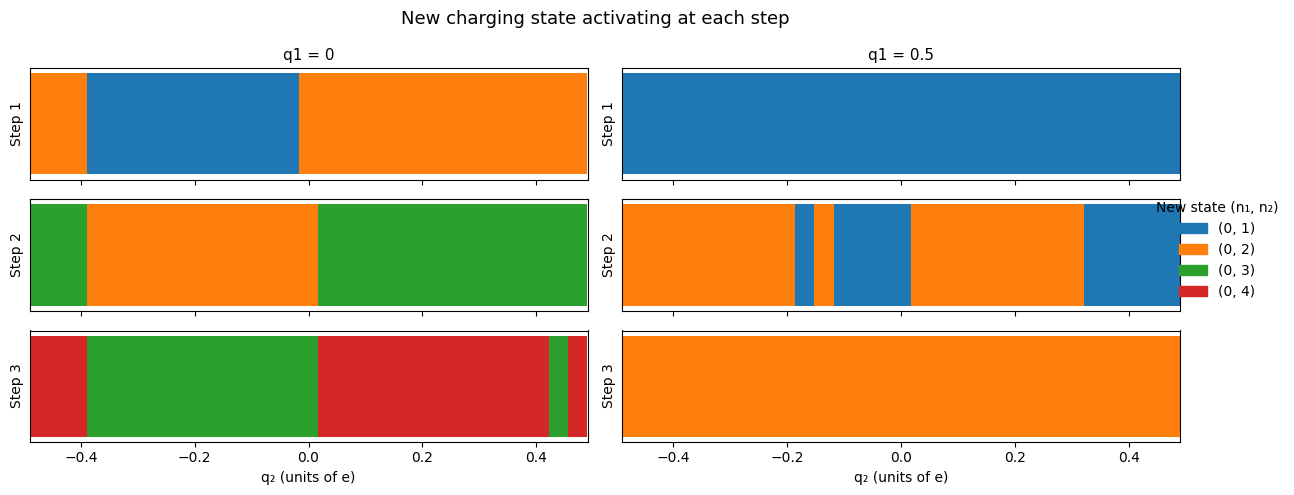

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# ── 1. DATA COLLECTION ────────────────────────────────────────────────────────

def get_dominant_state(cache):
    """Return the (n1, n2) state with highest probability."""
    (state, prob) = max(cache, key=lambda x: x[1])
    return tuple(state), prob  # ensure it's a plain tuple, not a mutable list


# Store results as:
#   state_data[label][step_num][q2_idx] = {
#       'q2': float, 'V_step': float,
#       'state_before': (n1,n2), 'state_after': (n1,n2)
#   }
state_data = {}

for q1_val, label in [(0.0, 'q1=0'), (0.5, 'q1=0.5')]:
    state_data[label] = {step: [] for step in range(3)}
    data = results_b[label]

    for idx, q2_val in enumerate(q2_values):
        for step_num in range(3):
            V_step = data[idx, step_num, 0]

            if np.isnan(V_step):
                state_data[label][step_num].append({
                    'q2': q2_val, 'V_step': np.nan,
                    'state_before': None, 'state_after': None
                })
                continue

            try:
                cache_before = get_cache_states(100, q1_val, q2_val, V_step - delta_V)
                cache_after  = get_cache_states(100, q1_val, q2_val, V_step + delta_V)

                s_before, _ = get_dominant_state(cache_before)
                s_after,  _ = get_dominant_state(cache_after)

                state_data[label][step_num].append({
                    'q2': q2_val, 'V_step': V_step,
                    'state_before': s_before, 'state_after': s_after
                })
            except Exception as e:
                state_data[label][step_num].append({
                    'q2': q2_val, 'V_step': np.nan,
                    'state_before': None, 'state_after': None
                })
                print(f'  Warning: {label}, step {step_num+1}, q2={q2_val:.3f}: {e}')


# ── 2. COMPACT TRANSITION SUMMARY ─────────────────────────────────────────────
# Instead of printing every q2 value, print only the *distinct regions*
# where the new state is constant, and flag where it switches.

def compress_to_regions(entries):
    """
    Given a list of dicts with keys 'q2', 'state_after',
    return a list of (q2_start, q2_end, state) for each constant region.
    """
    regions = []
    current_state = None
    q2_start = None

    for e in entries:
        s = e['state_after']
        q2 = e['q2']
        if s != current_state:
            if current_state is not None:
                regions.append((q2_start, prev_q2, current_state))
            current_state = s
            q2_start = q2
        prev_q2 = q2

    if current_state is not None:
        regions.append((q2_start, prev_q2, current_state))

    return regions


print('NEW CHARGING STATE AT EACH STEP')
print('=' * 60)

for label in ['q1=0', 'q1=0.5']:
    print(f'\n{label}')
    print('-' * 40)
    for step_num in range(3):
        entries  = state_data[label][step_num]
        regions  = compress_to_regions(entries)
        print(f'  Step {step_num+1}:')
        for (q2_start, q2_end, state) in regions:
            if state is None:
                print(f'    q2 ∈ [{q2_start:+.3f}, {q2_end:+.3f}]  →  (not detected)')
            else:
                # Also print what it transitions FROM, using first entry in region
                first_entry = next(e for e in entries if e['q2'] == q2_start)
                s_before = first_entry['state_before']
                print(f'    q2 ∈ [{q2_start:+.3f}, {q2_end:+.3f}]  :  '
                      f'{s_before} → {state}')


# ── 3. COLOR-BAND PLOT ────────────────────────────────────────────────────────
# Collect all unique "new states" across all steps and labels to assign colors.

all_new_states = set()
for label in state_data:
    for step_num in range(3):
        for e in state_data[label][step_num]:
            if e['state_after'] is not None:
                all_new_states.add(e['state_after'])

# Assign a consistent color to each state
palette = plt.cm.tab10.colors
state_list   = sorted(all_new_states)          # deterministic ordering
state_colors = {s: palette[i] for i, s in enumerate(state_list)}

fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(12, 5),
    sharey='row', sharex='col'
)
fig.suptitle('New charging state activating at each step', fontsize=13)

col_labels = ['q1 = 0', 'q1 = 0.5']

for col_idx, label in enumerate(['q1=0', 'q1=0.5']):
    for step_num in range(3):
        ax = axes[step_num, col_idx]
        entries = state_data[label][step_num]

        # Draw one thin horizontal bar per q2 point, colored by new state
        for e in entries:
            color = state_colors.get(e['state_after'], 'lightgrey')
            ax.barh(
                y=0, width=q2_values[1] - q2_values[0],  # bar width = q2 spacing
                left=e['q2'],
                color=color, edgecolor='none', height=0.8
            )

        ax.set_yticks([])
        ax.set_xlim(q2_values[0], q2_values[-1])
        ax.set_ylabel(f'Step {step_num+1}', fontsize=10)

        if step_num == 0:
            ax.set_title(col_labels[col_idx], fontsize=11)
        if step_num == 2:
            ax.set_xlabel('q₂ (units of e)', fontsize=10)

# Shared legend
legend_patches = [
    mpatches.Patch(color=state_colors[s], label=f'({s[0]}, {s[1]})')
    for s in state_list
]
fig.legend(
    handles=legend_patches,
    title='New state (n₁, n₂)',
    loc='center right',
    bbox_to_anchor=(1.08, 0.5),
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.savefig('task9d_state_bands.pdf', bbox_inches='tight')
plt.show()